### **Premisa**: Gonzalo recibio una herencia importante y quiere invertir el dinero en algo que genere capital de manera sostenida para no tener que trabajar mas. Una de las recomendaciones que recibio, ya que vive en BsAs, es iniciar una carrera como 'empresario Airbnb'. Esto suena bien, pero la decision de si es un buen negocio y de que forma encararlo (# de propiedades para comprar, tipo, ubicacion) parece dificil. Con el objetivo de tomar una decision informada, trabajaremos con el dataset de Inside Airbnb de Buenos Aires para tratar de encontrar una formula que aumente las chances de convertirse en un empresario Airbnb **exitoso** _(aun no sabemos lo que significa en terminos del ds)_

In [143]:
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from scipy.stats import describe
from scipy.stats import chi2_contingency, kendalltau, f_oneway, pointbiserialr
#import requests

In [144]:
def plot_pie(data, column, ax=None, startangle=90, palette='pastel', title=None):
    counts = data[column].value_counts()
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))
    
    ax.pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=startangle,
        colors=sns.color_palette(palette)
    )
    ax.set_title(title if title else f'Distribución de "{column}"')
    ax.legend(loc="best")
    ax.axis('equal') # Asegura que el gráfico sea circular

In [145]:
# Función para graficar
def plot_histograma(data, column, figsize=(6, 3), bins=15, kde=True, mvd=True, shade=True, snk=False):
    skewness = (data[column]).skew()
    kurtosis = (data[column]).kurt()
    media = (data[column]).mean()
    var = (data[column]).var()
    std = (data[column]).std()
    plt.figure(figsize=figsize)
    plt.grid(axis='y')
    sns.histplot(data[column], bins=bins, kde=kde)
    if snk:
        plt.figtext(0.7, 0.8, f'Asimetría: {skewness:.2f}', fontsize=10, color='blue')
        plt.figtext(0.715, 0.73, f'Curtosis: {kurtosis:.2f}', fontsize=10, color='blue')
        plt.axvline(media, color='red', linestyle='--', label='Media')

1. Cargamos el dataset de 'listings'. Hay uno resumido y otro extendido. El resumido parece mas util

In [146]:
df = pd.read_csv("listings_ext.csv")

2. Primera idea de que hay

In [147]:
pd. set_option('display.max_columns', None)
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,42610838,https://www.airbnb.com/rooms/42610838,20260125052844,2026-01-25,city scrape,"Puerto Madero a 3 cuadras, centro, bello , tea...","Unbeatable location half a block away, 50 mete...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,224049389,https://www.airbnb.com/users/show/224049389,1469188629918707060,https://www.airbnb.com/users/profile/146918862...,Gabriela,NaN,7,2,5,11,NaN,NaN,NaN,NaN,NaN,t,NaN,https://a0.muscache.com/im/pictures/user/ba7f6...,NaN,3,NaN,NaN,t,t,NaN,San Nicolas,NaN,-34.599976,-58.374195,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Kitchen"", ""Air conditioning"", ""Wifi"", ""TV""]",NaN,7.0,365.0,7.0,7.0,365.0,365.0,7.0,365.0,NaN,t,30,35,36,244,2026-01-25,0,0,0,220,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,0,0,NaN
1,1305876403852901802,https://www.airbnb.com/rooms/1305876403852901802,20260125052844,2026-01-25,city scrape,Apart estudio en Microcentro,"Located in the heart of Buenos Aires, this stu...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,25649070,https://www.airbnb.com/users/show/25649070,1465347917068117288,https://www.airbnb.com/users/profile/146534791...,Federico,NaN,11,0,3,7,"Autonomous City of Buenos Aires, Argentina",NaN,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/users/25649070/prof...,NaN,1,NaN,NaN,t,t,NaN,San Nicolas,NaN,-34.600382,-58.372692,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Paid parking on premises"", ""Air conditioning...",NaN,2.0,365.0,2.0,2.0,365.0,365.0,2.0,365.0,NaN,t,7,16,32,307,2026-01-25,1,0,0,283,1,0,NaN,2025-01-18,2025-01-18,3.00,4.00,2.00,3.00,3.00,5.00,4.00,NaN,NaN,1,1,0,0,0.08
2,1542233033640525302,https://www.airbnb.com/rooms/1542233033640525302,20260125052844,2026-01-25,city scrape,"Departamento en Buenos Aires, abasto shopping",From this central accommodation your group wil...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,153014015,https://www.airbnb.com/users/show/153014015,1468500000533080859,https://www.airbnb.com/users/profile/146850000...,Marco,NaN,8,3,7,10,"Olivos, Argentina",Responsable amable atento y amigable,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/pictures/user/4e988...,NaN,1,NaN,NaN,t,t,NaN,Balvanera,NaN,-34.603295,-58.409527,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,2.0,"[""Smoke alarm"", ""Wifi"", ""Kitchen"", ""Fire extin...",NaN,7.0,365.0,7.0,7.0,365.0,365.0,7.0,365.0,NaN,t,0,21,51,326,2026-01-25,0,0,0,302,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [148]:
df.shape

(27348, 85)

In [149]:
df.describe()

,id,scrape_id,neighborhood_overview,host_id,host_profile_id,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_response_time,host_response_rate,host_acceptance_rate,host_thumbnail_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,neighbourhood,neighbourhood_group_cleansed,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,2.734800e+04,2.734800e+04,0.0,2.734800e+04,2.734800e+04,0.0,27348.000000,27348.000000,27348.000000,27348.000000,0.0,0.0,0.0,0.0,0.0,27348.00000,0.0,0.0,0.0,0.0,27348.000000,27348.000000,27348.000000,27340.000000,27288.000000,27340.000000,0.0,27242.000000,27242.000000,27242.000000,27242.000000,27242.000000,27242.000000,27348.000000,27348.000000,0.0,27348.000000,27348.000000,27348.000000,27348.000000,27348.000000,27348.000000,27348.000000,27348.000000,27348.000000,27348.000000,0.0,24045.000000,24044.000000,24045.000000,24045.000000,24045.000000,24045.000000,24045.000000,0.0,27348.000000,27348.000000,27348.000000,27348.000000,24045.000000
mean,8.556780e+17,2.026013e+13,NaN,2.372763e+08,1.469892e+18,NaN,7.263346,5.282105,5.135695,5.067756,NaN,NaN,NaN,NaN,NaN,17.92398,NaN,NaN,NaN,NaN,-34.592076,-58.416340,2.951258,1.227871,1.164211,1.900914,NaN,4.748770,586.123009,4.748770,5.661112,567.889803,586.123009,5.283765,577.815409,NaN,14.345546,33.870630,56.173651,239.999963,38.127176,12.231827,0.858820,226.462886,12.192043,72.479450,NaN,4.779859,4.805344,4.737711,4.867613,4.861722,4.871776,4.740539,NaN,12.394398,11.769270,0.498866,0.051631,1.464834
std,5.477969e+17,0.000000e+00,NaN,2.233505e+08,1.837567e+16,NaN,3.984068,3.534070,3.966324,3.546789,NaN,NaN,NaN,NaN,NaN,38.39527,NaN,NaN,NaN,NaN,0.017927,0.029938,1.565807,0.674879,0.909412,1.522315,NaN,16.434273,434.066284,16.434273,17.751551,435.493314,434.066284,17.086619,431.715752,NaN,10.924438,20.876676,29.730819,113.614547,56.082583,17.429681,1.551164,105.528070,17.510414,80.940829,NaN,0.355719,0.342739,0.376956,0.291768,0.302366,0.252090,0.371888,NaN,27.895493,27.868739,2.349324,0.691514,1.559983
min,1.150800e+04,2.026013e+13,NaN,1.342600e+04,1.462507e+18,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,1.00000,NaN,NaN,NaN,NaN,-34.690056,-58.530890,1.000000,0.000000,0.000000,0.000000,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,1.000000,0.000000,0.000000,0.000000,0.010000
25%,5.626035e+17,2.026013e+13,NaN,3.427341e+07,1.462899e+18,NaN,3.000000,2.000000,2.000000,2.000000,NaN,NaN,NaN,NaN,NaN,1.00000,NaN,NaN,NaN,NaN,-34.603202,-58.435973,2.000000,1.000000,1.000000,1.000000,NaN,1.000000,365.000000,1.000000,2.000000,190.000000,365.000000,2.000000,360.000000,NaN,3.000000,16.000000,33.000000,151.000000,4.000000,1.000000,0.000000,149.000000,1.000000,6.000000,NaN,4.730000,4.770000,4.670000,4.850000,4.840000,4.850000,4.680000,NaN,1.000000,1.000000,0.000000,0.000000,0.390000
50%,9.886724e+17,2.026013e+13,NaN,1.587017e+08,1.466928e+18,NaN,8.000000,5.000000,4.000000,5.000000,NaN,NaN,NaN,NaN,NaN,3.00000,NaN,NaN,

In [150]:
num_cols = df.select_dtypes(include=['number']).shape[1]
str_cols = df.select_dtypes(include=['object', 'string']).shape[1]

print("Atributos numericos:", num_cols)
print("Atributos string:", str_cols)

Atributos numericos: 60
Atributos string: 25


27348 obs, 85 atributos, la mayoria numericos pero posiblemente muchos de ellos de poco interes. Por ello hay que hacer EDA

In [151]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27348 entries, 0 to 27347
Data columns (total 85 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            27348 non-null  int64  
 1   listing_url                                   27348 non-null  str    
 2   scrape_id                                     27348 non-null  int64  
 3   last_scraped                                  27348 non-null  str    
 4   source                                        27348 non-null  str    
 5   name                                          27348 non-null  str    
 6   description                                   26752 non-null  str    
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   27347 non-null  str    
 9   host_id                                       27348 non-null  int64  
 1

3. Contamos cantidad de nulos

In [152]:
pd.options.display.min_rows = 115
print(df.isnull().sum(axis=0).sort_values(ascending=False))

neighborhood_overview                           27348
host_since                                      27348
host_acceptance_rate                            27348
host_response_rate                              27348
host_response_time                              27348
host_total_listings_count                       27348
host_verifications                              27348
neighbourhood_group_cleansed                    27348
instant_bookable                                27348
calendar_updated                                27348
estimated_revenue_l365d                         27348
price                                           27348
neighbourhood                                   27348
host_thumbnail_url                              27348
host_neighbourhood                              27348
license                                         26887
host_about                                      11784
host_location                                    5783
review_scores_accuracy      

Eliminamos los atributos vacios

In [153]:
df3_1 = df.drop(columns=['calendar_updated', 'host_since', 'neighbourhood_group_cleansed','neighbourhood','host_verifications','host_total_listings_count','host_neighbourhood','host_thumbnail_url','host_acceptance_rate','host_response_rate','host_response_time','estimated_revenue_l365d', 'price', 'neighborhood_overview', 'instant_bookable', 'license', 'host_about'])
df3_1.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_is_superhost,host_picture_url,host_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,42610838,https://www.airbnb.com/rooms/42610838,20260125052844,2026-01-25,city scrape,"Puerto Madero a 3 cuadras, centro, bello , tea...","Unbeatable location half a block away, 50 mete...",https://a0.muscache.com/pictures/miso/Hosting-...,224049389,https://www.airbnb.com/users/show/224049389,1469188629918707060,https://www.airbnb.com/users/profile/146918862...,Gabriela,7,2,5,11,NaN,t,https://a0.muscache.com/im/pictures/user/ba7f6...,3,t,t,San Nicolas,-34.599976,-58.374195,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Kitchen"", ""Air conditioning"", ""Wifi"", ""TV""]",7.0,365.0,7.0,7.0,365.0,365.0,7.0,365.0,t,30,35,36,244,2026-01-25,0,0,0,220,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,0,0,NaN
1,1305876403852901802,https://www.airbnb.com/rooms/1305876403852901802,20260125052844,2026-01-25,city scrape,Apart estudio en Microcentro,"Located in the heart of Buenos Aires, this stu...",https://a0.muscache.com/pictures/miso/Hosting-...,25649070,https://www.airbnb.com/users/show/25649070,1465347917068117288,https://www.airbnb.com/users/profile/146534791...,Federico,11,0,3,7,"Autonomous City of Buenos Aires, Argentina",f,https://a0.muscache.com/im/users/25649070/prof...,1,t,t,San Nicolas,-34.600382,-58.372692,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Paid parking on premises"", ""Air conditioning...",2.0,365.0,2.0,2.0,365.0,365.0,2.0,365.0,t,7,16,32,307,2026-01-25,1,0,0,283,1,0,2025-01-18,2025-01-18,3.00,4.00,2.00,3.00,3.00,5.00,4.00,1,1,0,0,0.08
2,1542233033640525302,https://www.airbnb.com/rooms/1542233033640525302,20260125052844,2026-01-25,city scrape,"Departamento en Buenos Aires, abasto shopping",From this central accommodation your group wil...,https://a0.muscache.com/pictures/hosting/Hosti...,153014015,https://www.airbnb.com/users/show/153014015,1468500000533080859,https://www.airbnb.com/users/profile/146850000...,Marco,8,3,7,10,"Olivos, Argentina",f,https://a0.muscache.com/im/pictures/user/4e988...,1,t,t,Balvanera,-34.603295,-58.409527,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,2.0,"[""Smoke alarm"", ""Wifi"", ""Kitchen"", ""Fire extin...",7.0,365.0,7.0,7.0,365.0,365.0,7.0,365.0,t,0,21,51,326,2026-01-25,0,0,0,302,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0,0,NaN
3,1004530078359434134,https://www.airbnb.com/rooms/1004530078359434134,20260125052844,2026-01-25,city scrape,Departamento en Recoleta,Relax with the whole family at this peaceful p...,https://a0.muscache.com/pictures/0beb83d5-381d...,1409800,https://www.airbnb.com/users/show/1409800,1462517876404348407,https://www.airbnb.com/users/profile/146251787...,Marian,14,2,14,1,"Buenos Aires, Argentina",f,https://a0.muscache.com/im/pictures/user/User-...,48,t,t,Balvanera,-34.599230,-58.407060,Entire rental unit,En

In [154]:
df3_1.shape

(27348, 68)

Eliminamos otras columnas que parecen irrelevantes a nuestro problema. Se eliminan todas la variables relacionadas a el tipo de propiedad que tienen cada huesped, si tienen o no foto, la cantidad de propiedades por huesped

In [155]:
pd.options.display.max_columns = 85
df3_2 = df3_1.drop(columns=['host_has_profile_pic', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes','calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms','reviews_per_month', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights','minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'bathrooms_text', 'minimum_minimum_nights', 'name', 'description', 'host_name', 'first_review', 'last_review', 'host_url', 'last_scraped', 'listing_url', 'scrape_id', 'source','picture_url','host_profile_id','host_profile_url','host_location','host_picture_url','calendar_last_scraped'])#,'host_thumbnail_url'])#
df3_2.head()

,id,host_id,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_is_superhost,host_listings_count,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,amenities,minimum_nights,maximum_nights,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
0,42610838,224049389,7,2,5,11,t,3,t,San Nicolas,-34.599976,-58.374195,Entire rental unit,Entire home/apt,2,1.0,1.0,1.0,"[""Kitchen"", ""Air conditioning"", ""Wifi"", ""TV""]",7.0,365.0,t,30,35,36,244,0,0,0,220,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1305876403852901802,25649070,11,0,3,7,f,1,t,San Nicolas,-34.600382,-58.372692,Entire rental unit,Entire home/apt,2,1.0,1.0,1.0,"[""Paid parking on premises"", ""Air conditioning...",2.0,365.0,t,7,16,32,307,1,0,0,283,1,0,3.00,4.00,2.00,3.00,3.00,5.00,4.00
2,1542233033640525302,153014015,8,3,7,10,f,1,t,Balvanera,-34.603295,-58.409527,Entire rental unit,Entire home/apt,2,1.0,1.0,2.0,"[""Smoke alarm"", ""Wifi"", ""Kitchen"", ""Fire extin...",7.0,365.0,t,0,21,51,326,0,0,0,302,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1004530078359434134,1409800,14,2,14,1,f,48,t,Balvanera,-34.599230,-58.407060,Entire rental unit,Entire home/apt,2,1.0,1.0,1.0,"[""Bathtub"", ""Hair dryer"", ""Exterior security c...",1.0,365.0,t,30,60,90,365,22,3,0,341,3,18,4.73,4.64,4.64,4.82,4.73,4.59,4.45
4,800145927121871422,467965425,3,6,2,8,f,2,t,Almagro,-34.599767,-58.426499,Entire rental unit,Entire home/apt,4,1.0,2.0,3.0,"[""Outdoor shower"", ""Dedicated workspace"", ""BBQ...",1.0,365.0,NaN,30,60,90,365,0,0,0,341,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Vamos a verificar la correlacion entre todas las variables numericas

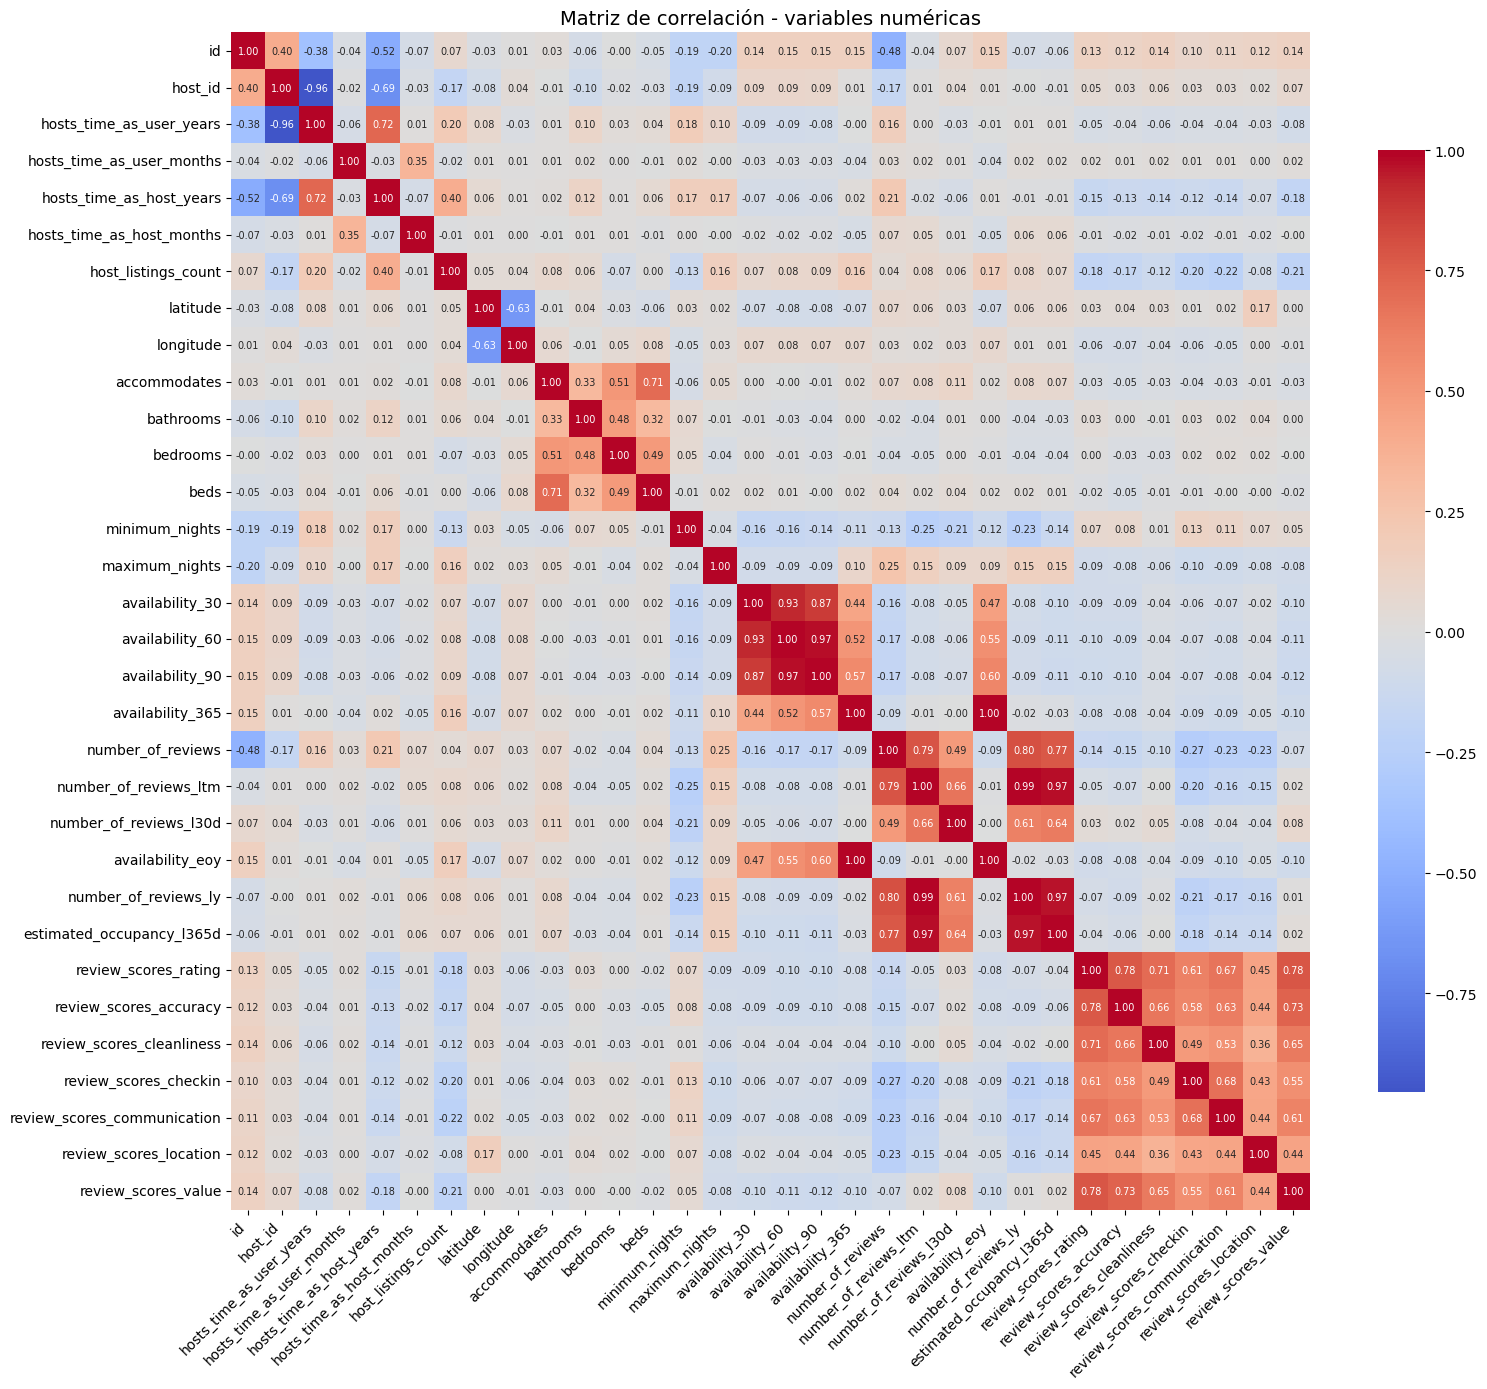

In [156]:
# Seleccionar solo las columnas numéricas de la lista
numerical_cols = df3_2.select_dtypes(include=['number']).columns

# Calcular matriz de correlación Spearman
corr = df3_2[numerical_cols].corr(method='spearman')

# Graficar
plt.figure(figsize=(16, 14))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, 
            annot_kws={"size": 7}, cbar_kws={"shrink": 0.8})
plt.title("Matriz de correlación - variables numéricas", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Reducción de dimensionalidad por correlación entre variables numéricas

A partir de la matriz de correlación de Spearman, identificamos tres grupos de 
variables altamente correlacionadas entre sí, lo que indica redundancia de información:

**Grupo 1 - Review scores**: `review_scores_rating`, `accuracy`, `cleanliness`, 
`checkin`, `communication` y `value` presentan correlaciones superiores a 0.55 entre sí. 
Conservamos `review_scores_rating` como representante del grupo (es la variable con 
correlaciones más altas y consistentes con el resto) y `review_scores_location`, 
que mantiene correlaciones bajas (~0.44) y por lo tanto aporta información distinta.

**Grupo 2 - Availability**: `availability_30`, `availability_90`, `availability_365` 
y `availability_eoy` presentan correlación moderada-alta con `availability_60` 
(mínimo 0.52). Conservamos únicamente `availability_60` como representante del grupo.

**Grupo 3 - Reviews/Occupancy**: `number_of_reviews`, `number_of_reviews_l30d`, 
`number_of_reviews_ly` y `estimated_occupancy_l365d` presentan correlación de al 
menos 0.66 con `number_of_reviews_ltm`. Conservamos `number_of_reviews_ltm` como 
representante del grupo.

Con esta reducción pasamos de 13 variables potencialmente redundantes a 4, 
disminuyendo la dimensionalidad sin perder información relevante para el análisis.

In [157]:
columnas_eliminar = [
    # Grupo 1 - Review scores
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_value',
    
    # Grupo 2 - Availability
    'availability_30',
    'availability_90',
    'availability_365',
    'availability_eoy',
    
    # Grupo 3 - Reviews/Occupancy
    'number_of_reviews',
    'number_of_reviews_l30d',
    'number_of_reviews_ly',
    'estimated_occupancy_l365d',
]

df3_2 = df3_2.drop(columns=columnas_eliminar).copy()
print(df3_2.shape)
print(df3_2.columns.tolist())

(27348, 26)
['id', 'host_id', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_is_superhost', 'host_listings_count', 'host_identity_verified', 'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'amenities', 'minimum_nights', 'maximum_nights', 'has_availability', 'availability_60', 'number_of_reviews_ltm', 'review_scores_rating', 'review_scores_location']


In [158]:
df3_2.describe()

,id,host_id,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,availability_60,number_of_reviews_ltm,review_scores_rating,review_scores_location
count,2.734800e+04,2.734800e+04,27348.000000,27348.000000,27348.000000,27348.000000,27348.00000,27348.000000,27348.000000,27348.000000,27340.000000,27288.000000,27340.000000,27242.000000,27242.000000,27348.000000,27348.000000,24045.000000,24045.000000
mean,8.556780e+17,2.372763e+08,7.263346,5.282105,5.135695,5.067756,17.92398,-34.592076,-58.416340,2.951258,1.227871,1.164211,1.900914,4.748770,586.123009,33.870630,12.231827,4.779859,4.871776
std,5.477969e+17,2.233505e+08,3.984068,3.534070,3.966324,3.546789,38.39527,0.017927,0.029938,1.565807,0.674879,0.909412,1.522315,16.434273,434.066284,20.876676,17.429681,0.355719,0.252090
min,1.150800e+04,1.342600e+04,0.000000,0.000000,0.000000,0.000000,1.00000,-34.690056,-58.530890,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
25%,5.626035e+17,3.427341e+07,3.000000,2.000000,2.000000,2.000000,1.00000,-34.603202,-58.435973,2.000000,1.000000,1.000000,1.000000,1.000000,365.000000,16.000000,1.000000,4.730000,4.850000
50%,9.886724e+17,1.587017e+08,8.000000,5.000000,4.000000,5.000000,3.00000,-34.591370,-58.418325,2.000000,1.000000,1.000000,1.000000,2.000000,365.000000,37.000000,5.000000,4.870000,4.940000
75%,1.293344e+18,4.600936e+08,10.000000,8.000000,8.000000,8.000000,16.00000,-34.581471,-58.391140,4.000000,1.000000,1.000000,2.000000,3.000000,1125.000000,54.000000,17.000000,4.980000,5.000000
max,1.605545e+18,7.420151e+08,16.000000,11.000000,15.000000,11.000000,945.00000,-34.535630,-58.355403,16.000000,22.000000,22.000000,40.000000,730.000000,1825.000000,60.000000,329.000000,5.000000,5.000000


### Variables numericas

| Variable | Descripción | Tipo | Observación |
|---|---|---|---|
| `id` | Identificador del alojamiento | Discreta | Identificador, sin sentido aritmético |
| `hosts_time_as_user_years` | Cantidad de años de host como usuario | Discreta | Toma valores enteros positivos |
| `hosts_time_as_user_months` | Cantidad de meses de host como usuario (unificada) | Discreta | Toma valores enteros positivos |
| `hosts_time_as_host_years` | Cantidad de años como host | Discreta | Toma valores enteros positivos |
| `hosts_time_as_host_months` | Cantidad de meses como host (unificada) | Discreta | Toma valores enteros positivos |
| `host_listings_count` | Cantidad de propiedades que tiene publicadas el usuario | Discreta | Toma valores enteros positivos, posible outlier (max 945) |
| `latitude` | Coordenada geográfica norte-sur del alojamiento | Continua | Coordenada geoespacial |
| `longitude` | Coordenada geográfica este-oeste del alojamiento | Continua | Coordenada geoespacial |
| `accommodates` | Número máximo de huéspedes en una estadía | Discreta | Toma valores enteros positivos |
| `bathrooms` | Cantidad de baños en la propiedad | Discreta | Toma valores enteros positivos, nulos (0.03%) |
| `bedrooms` | Cantidad de dormitorios en la propiedad | Discreta | Toma valores enteros positivos, nulos (0.22%) |
| `beds` | Cantidad de camas en la propiedad | Discreta | Toma valores enteros positivos, nulos (0.03%) |
| `minimum_nights` | Cantidad mínima de noches | Discreta | Toma valores enteros positivos, nulos (0.39%) |
| `maximum_nights` | Cantidad máxima de noches | Discreta | Toma valores enteros positivos, nulos (0.39%) |
| `availability_60` | Disponibilidad en 60 días | Discreta | Representante del grupo de availability (alta correlación con 30/90/365/eoy) |
| `number_of_reviews_ltm` | Cantidad de reseñas en el último año | Discreta | Representante del grupo de reviews (alta correlación con number_of_reviews, l30d, ly, occupancy) |
| `review_scores_rating` | Puntaje general del listing | Continua | Valores entre 1 y 5, nulos (12.08%) |
| `review_scores_location` | Puntaje de ubicación del listing | Continua | Valores entre 1 y 5, nulos (12.08%), baja correlación con el resto |

### Variables categoricas

| Variable | Descripción | Tipo | Observación |
|---|---|---|---|
| `id` | Identificador del alojamiento | Discreta | Identificador, sin sentido aritmético |
| `hosts_time_as_user_years` | Cantidad de años de host como usuario | Discreta | Toma valores enteros positivos |
| `hosts_time_as_user_months` | Cantidad de meses de host como usuario (unificada) | Discreta | Toma valores enteros positivos |
| `hosts_time_as_host_years` | Cantidad de años como host | Discreta | Toma valores enteros positivos |
| `hosts_time_as_host_months` | Cantidad de meses como host (unificada) | Discreta | Toma valores enteros positivos |
| `host_listings_count` | Cantidad de propiedades que tiene publicadas el usuario | Discreta | Toma valores enteros positivos, posible outlier (max 945) |
| `latitude` | Coordenada geográfica norte-sur del alojamiento | Continua | Coordenada geoespacial |
| `longitude` | Coordenada geográfica este-oeste del alojamiento | Continua | Coordenada geoespacial |
| `accommodates` | Número máximo de huéspedes en una estadía | Discreta | Toma valores enteros positivos |
| `bathrooms` | Cantidad de baños en la propiedad | Discreta | Toma valores enteros positivos, nulos (0.03%) |
| `bedrooms` | Cantidad de dormitorios en la propiedad | Discreta | Toma valores enteros positivos, nulos (0.22%) |
| `beds` | Cantidad de camas en la propiedad | Discreta | Toma valores enteros positivos, nulos (0.03%) |
| `minimum_nights` | Cantidad mínima de noches | Discreta | Toma valores enteros positivos, nulos (0.39%) |
| `maximum_nights` | Cantidad máxima de noches | Discreta | Toma valores enteros positivos, nulos (0.39%) |
| `availability_60` | Disponibilidad en 60 días | Discreta | Representante del grupo de availability (alta correlación con 30/90/365/eoy) |
| `number_of_reviews_ltm` | Cantidad de reseñas en el último año | Discreta | Representante del grupo de reviews (alta correlación con number_of_reviews, l30d, ly, occupancy) |
| `review_scores_rating` | Puntaje general del listing | Continua | Valores entre 1 y 5, nulos (12.08%) |
| `review_scores_location` | Puntaje de ubicación del listing | Continua | Valores entre 1 y 5, nulos (12.08%), baja correlación con el resto |

## esta tabla de abajo no va mas es la de arriba la que queda

| Variable | Descripción | Tipo | Observación |
|---|---|---|---|
| `id` | Identificador del alojamiento | Discreta | Identificador, sin sentido aritmético |
| `hosts_time_as_user_years` | Cantidad de anios de host como usuario | Discreta | Toma valores enteros positivos |
| `hosts_time_as_user_months` | Identificador del anfitrión | Discreta | Toma valores enteros positivos |
| `hosts_time_as_host_years` | Identificador del anfitrión | Discreta | Toma valores enteros positivos |
| `hosts_time_as_host_months` | Identificador del anfitrión | Discreta | Toma valores enteros positivos |
| `host_is_superhost` | Estatus de superhost | Categorica binaria | **TARGET** |
| `host_listings_count` | Cantidad de propiedades que tiene publicadas el usuario | Discreta | Toma valores enteros positivos |
| `host_identity_verified` | Identidad del host validada | Categorica binaria | Puede tener asociacion con el target |
| `neighbourhood_cleansed` | Barrio del listing | Categorica nominal | Texto, cardinalidad media |
| `latitude` | Coordenada geográfica norte-sur del alojamiento | Discreta | Toma valores enteros |
| `longitude` | Coordenada geográfica este-oeste del alojamiento | Discreta | Toma valores enteros |
| `property_type` | Tipo de propiedad | Categorica nominal | Baja cardinalidad |
| `accommodates` | Numero maximo de huespedes en una estadia | Discreta | Toma valores enteros positivos |
| `bathrooms` | Cantidad de banios en la propiedad | Discreta | Toma valores enteros positivos |
| `bedrooms` | Cantidad de dormitorios en la propiedad | Discreta | Toma valores enteros positivos |
| `beds` | Cantidad de camas en la propiedad | Discreta | Toma valores enteros positivos |
| `amenities` | Amenities disponibles en la propiedad | Categorica nominal | Baja cardinalidad |
| `minimum_nights` | Cantidad minima de noches | Discreta | Toma valores enteros positivos |
| `maximum_nights` | Cantidad maxima de noches | Discreta | Toma valores enteros positivos |
| `has_availability` | Disponibilidad | Nominal binaria | Puede tener asociacion con el target |
| `availability_30` | Disponibilidad en 30 dias | Discreta | Toma valores enteros positivos |
| `availability_60` | Disponibilidad en 60 dias | Discreta | Toma valores enteros positivos |
| `availability_90` | Disponibilidad en 90 dias | Discreta | Toma valores enteros positivos |
| `availability_365` | Disponibilidad en 365 dias | Discreta | Toma valores enteros positivos |
| `number_of_reviews` | Cantidad de reviews del listing | Discreta | Toma valores enteros positivos |
| `estimated_occupancy_l365d` | Ocupacion ultimo anio | Discreta | Toma valores enteros positivos |
| `review_scores_rating` | Puntaje del listing | Numerica continua| Toma valores enteros entre 1 y 5 |
| `review_scores_accuracy` | Precio por noche | Numerica continua| Toma valores enteros entre 1 y 5 |
| `review_scores_cleanliness` | Precio por noche | Numerica continua| Toma valores enteros entre 1 y 5 |
| `review_scores_checkin` | Precio por noche | Numerica continua| Toma valores enteros entre 1 y 5 |
| `review_scores_communication` | Precio por noche | Numerica continua| Toma valores enteros entre 1 y 5 |
| `review_scores_value` | Precio por noche | Numerica continua| Toma valores enteros entre 1 y 5 |

Creamos nuevos features con el tiempo del host como usuario y como host en meses para poder usarlos en analisis, y ademas tomamos la variable target host_is_superhost, para cambiaar los valors 't'= 1 y 'f'=0

In [159]:
df3_3 = df3_2
df3_3['hosts_time_as_user_months'] = df3_3['hosts_time_as_user_years'] * 12 + df3_3['hosts_time_as_user_months']
df3_3['hosts_time_as_host_months'] = df3_3['hosts_time_as_host_years'] * 12 + df3_3['hosts_time_as_host_months']
df3_3 = df3_3.drop(columns=['hosts_time_as_user_years', 'hosts_time_as_host_years']).copy()
df3_3["host_is_superhost"] = df["host_is_superhost"].map({'t': 1, 'f': 0})
df3_3.head()

,id,host_id,hosts_time_as_user_months,hosts_time_as_host_months,host_is_superhost,host_listings_count,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,amenities,minimum_nights,maximum_nights,has_availability,availability_60,number_of_reviews_ltm,review_scores_rating,review_scores_location
0,42610838,224049389,86,71,1,3,t,San Nicolas,-34.599976,-58.374195,Entire rental unit,Entire home/apt,2,1.0,1.0,1.0,"[""Kitchen"", ""Air conditioning"", ""Wifi"", ""TV""]",7.0,365.0,t,35,0,NaN,NaN
1,1305876403852901802,25649070,132,43,0,1,t,San Nicolas,-34.600382,-58.372692,Entire rental unit,Entire home/apt,2,1.0,1.0,1.0,"[""Paid parking on premises"", ""Air conditioning...",2.0,365.0,t,16,0,3.00,5.00
2,1542233033640525302,153014015,99,94,0,1,t,Balvanera,-34.603295,-58.409527,Entire rental unit,Entire home/apt,2,1.0,1.0,2.0,"[""Smoke alarm"", ""Wifi"", ""Kitchen"", ""Fire extin...",7.0,365.0,t,21,0,NaN,NaN
3,1004530078359434134,1409800,170,169,0,48,t,Balvanera,-34.599230,-58.407060,Entire rental unit,Entire home/apt,2,1.0,1.0,1.0,"[""Bathtub"", ""Hair dryer"", ""Exterior security c...",1.0,365.0,t,60,3,4.73,4.59
4,800145927121871422,467965425,42,32,0,2,t,Almagro,-34.599767,-58.426499,Entire rental unit,Entire home/apt,4,1.0,2.0,3.0,"[""Outdoor shower"", ""Dedicated workspace"", ""BBQ...",1.0,365.0,NaN,60,0,NaN,NaN


Vamos a analizar la relacon entre las varibles 'room_type' y 'property_type'.  Como vemos room_type es una agrupamiento de las caracteristicas de property_type. Por lo tanto vamos a eliminar la columna property_type

In [160]:
df3_3[['room_type', 'property_type']].value_counts()

room_type        property_type                     
Entire home/apt  Entire rental unit                    19895
                 Entire condo                           2774
                 Entire serviced apartment               846
Private room     Private room in rental unit             838
                 Private room in home                    624
Entire home/apt  Entire loft                             605
                 Entire home                             416
                 Entire vacation home                    166
Private room     Private room in condo                   157
                 Room in hotel                           154
                 Private room in guesthouse               94
                 Private room in casa particular          93
                 Private room in bed and breakfast        62
                 Private room in serviced apartment       56
                 Private room in townhouse                44
Entire home/apt  Entire townhouse

Hacemos una verifiacion por CremmerV  para ver si mantiene realcion con el target

In [161]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    min_dim = min(ct.shape) - 1
    return np.sqrt(chi2 / (n * min_dim))

v_room = cramers_v(df3_3['room_type'], df3_3['host_is_superhost'])
print(f"Cramér's V room_type vs target: {v_room:.4f}")

Cramér's V room_type vs target: 0.0961


Entonces eliminamos la variable property_type

In [162]:
df3_3 = df3_3.drop(columns=['property_type']).copy()


Los amenities son un atributo muy interesante porque nos puede guiar con respecto a que propiedades comprar o como equiparlas. Sin embargo, ese atributo tiene demasiadas palabras. Vamos a encontrar el top 10 de palabras mas frecuentes y considerar si vale la pena crear nuevos atributos con ellas
Concatenamos todo el texto en una sola linea, lo pasamos a minuscula, contamos la frecuencia de palabras, imprimimos, filtramos palabras que no son de utilidad y repetimos el proceso sin las palabras filtradas hasta que el top 10 son palabras utiles

In [163]:
from collections import Counter
import re

# Combine all text in the column into one big string
texto = " ".join(df3_3["amenities"].astype(str))

# Convert to lowercase and extract words
palabras = re.findall(r"\b\w+\b", texto.lower())

borrar = ['and', 'allowed', 'water', 'hot', 'clothing', 'in', 'dishes', 'silverware', 'heating', 'basics', 'refrigerator', 'cooking', 'dining', 'hangers', 'maker', 'bed']

palabras = [w for w in palabras if w not in borrar]

# Count word frequencies
frecuancias = Counter(palabras)

# Get the top 10
top_10 = frecuancias.most_common(10)

print(top_10)

[('coffee', 28636), ('wifi', 28026), ('kitchen', 26058), ('dryer', 24364), ('parking', 23796), ('tv', 20178), ('linens', 19906), ('paid', 18968), ('air', 18716), ('conditioning', 18711)]


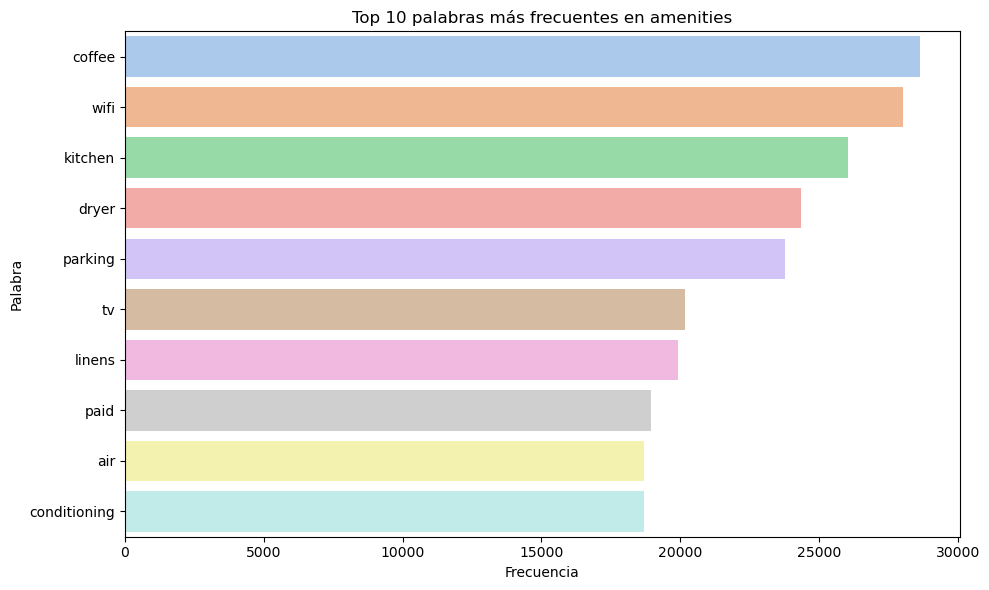

In [164]:
top_10_df = pd.DataFrame(top_10, columns=['palabra', 'frecuencia'])

plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_df, x='frecuencia', y='palabra', 
            hue='palabra', legend=False, palette='pastel')
plt.title('Top 10 palabras más frecuentes en amenities')
plt.xlabel('Frecuencia')
plt.ylabel('Palabra')
plt.tight_layout()
plt.show()

Ahora creamos features binarios con las mejores palabras

In [165]:
df3_3["coffee"] = df3_3["amenities"].str.contains("coffee", case=False, na=False).astype(int)
df3_3["wifi"] = df3_3["amenities"].str.contains("wifi", case=False, na=False).astype(int)
df3_3["parking"] = df3_3["amenities"].str.contains("parking", case=False, na=False).astype(int)
df3_3["air_conditioning"] = df3_3["amenities"].str.contains("conditioning", case=False, na=False).astype(int)
df3_3["pool"] = df3_3["amenities"].str.contains("pool", case=False, na=False).astype(int)
df3_3["gym"] = df3_3["amenities"].str.contains("gym", case=False, na=False).astype(int)
df3_3 = df3_3.drop(columns=['amenities']).copy()
df3_3.head()

,id,host_id,hosts_time_as_user_months,hosts_time_as_host_months,host_is_superhost,host_listings_count,host_identity_verified,neighbourhood_cleansed,latitude,longitude,room_type,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,has_availability,availability_60,number_of_reviews_ltm,review_scores_rating,review_scores_location,coffee,wifi,parking,air_conditioning,pool,gym
0,42610838,224049389,86,71,1,3,t,San Nicolas,-34.599976,-58.374195,Entire home/apt,2,1.0,1.0,1.0,7.0,365.0,t,35,0,NaN,NaN,0,1,0,1,0,0
1,1305876403852901802,25649070,132,43,0,1,t,San Nicolas,-34.600382,-58.372692,Entire home/apt,2,1.0,1.0,1.0,2.0,365.0,t,16,0,3.00,5.00,0,1,1,1,0,0
2,1542233033640525302,153014015,99,94,0,1,t,Balvanera,-34.603295,-58.409527,Entire home/apt,2,1.0,1.0,2.0,7.0,365.0,t,21,0,NaN,NaN,0,1,0,1,0,0
3,1004530078359434134,1409800,170,169,0,48,t,Balvanera,-34.599230,-58.407060,Entire home/apt,2,1.0,1.0,1.0,1.0,365.0,t,60,3,4.73,4.59,0,1,0,1,0,0
4,800145927121871422,467965425,42,32,0,2,t,Almagro,-34.599767,-58.426499,Entire home/apt,4,1.0,2.0,3.0,1.0,365.0,NaN,60,0,NaN,NaN,0,1,1,1,1,0


In [166]:
df3_3.describe()

,id,host_id,hosts_time_as_user_months,hosts_time_as_host_months,host_is_superhost,host_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,availability_60,number_of_reviews_ltm,review_scores_rating,review_scores_location,coffee,wifi,parking,air_conditioning,pool,gym
count,2.734800e+04,2.734800e+04,27348.000000,27348.000000,27348.000000,27348.00000,27348.000000,27348.000000,27348.000000,27340.000000,27288.000000,27340.000000,27242.000000,27242.000000,27348.000000,27348.000000,24045.000000,24045.000000,27348.000000,27348.000000,27348.000000,27348.000000,27348.000000,27348.000000
mean,8.556780e+17,2.372763e+08,92.442263,66.696102,0.419994,17.92398,-34.592076,-58.416340,2.951258,1.227871,1.164211,1.900914,4.748770,586.123009,33.870630,12.231827,4.779859,4.871776,0.652625,0.991736,0.569329,0.683889,0.267625,0.127761
std,5.477969e+17,2.233505e+08,47.751239,47.515290,0.493567,38.39527,0.017927,0.029938,1.565807,0.674879,0.909412,1.522315,16.434273,434.066284,20.876676,17.429681,0.355719,0.252090,0.476145,0.090531,0.495179,0.464965,0.442729,0.333829
min,1.150800e+04,1.342600e+04,0.000000,0.000000,0.000000,1.00000,-34.690056,-58.530890,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.626035e+17,3.427341e+07,45.000000,28.000000,0.000000,1.00000,-34.603202,-58.435973,2.000000,1.000000,1.000000,1.000000,1.000000,365.000000,16.000000,1.000000,4.730000,4.850000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,9.886724e+17,1.587017e+08,100.000000,49.000000,0.000000,3.00000,-34.591370,-58.418325,2.000000,1.000000,1.000000,1.000000,2.000000,365.000000,37.000000,5.000000,4.870000,4.940000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
75%,1.293344e+18,4.600936e+08,128.000000,100.000000,1.000000,16.00000,-34.581471,-58.391140,4.000000,1.000000,1.000000,2.000000,3.000000,1125.000000,54.000000,17.000000,4.980000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,1.605545e+18,7.420151e+08,201.000000,180.000000,1.000000,945.00000,-34.535630,-58.355403,16.000000,22.000000,22.000000,40.000000,730.000000,1825.000000,60.000000,329.000000,5.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Si observamos los datos para valores minimos, se ve que hay listings sin banios, habitaciones o camas. Esto puede ser tanto errores MAR como listings de arreglos poco ortodoxos. 
Vamos a anlizar la catidad de cada uno de ellos, por lo tanto habitacion = 0  puede ser un monoambiente y son el 12,79% de las variables. En el caso de bed y bathroom representan el 2,63% y 0,43%

In [167]:
variables = ['bathrooms', 'beds']

for var in variables:
    ceros = (df3_3[var] == 0).sum()
    nulos = df3_3[var].isnull().sum()
    total = len(df3_3)
    print(f"{var}:")
    print(f"  == 0:   {ceros} registros ({ceros/total*100:.2f}%)")
    print(f"  NaN:    {nulos} registros ({nulos/total*100:.2f}%)")
    print()

bathrooms:
  == 0:   118 registros (0.43%)
  NaN:    8 registros (0.03%)

beds:
  == 0:   719 registros (2.63%)
  NaN:    8 registros (0.03%)



In [168]:
print(df3_3[df3_3['beds'] == 0]['room_type'].value_counts())

room_type
Entire home/apt    614
Private room        52
Hotel room          50
Shared room          3
Name: count, dtype: int64


In [169]:
df3_4 = df3_3[df3_3["bathrooms"].notna() & (df3_3["bathrooms"] != 0)]
df3_4 = df3_4[df3_4["beds"].notna() & (df3_4["beds"] != 0)]

df3_4.describe()

,id,host_id,hosts_time_as_user_months,hosts_time_as_host_months,host_is_superhost,host_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,availability_60,number_of_reviews_ltm,review_scores_rating,review_scores_location,coffee,wifi,parking,air_conditioning,pool,gym
count,2.650600e+04,2.650600e+04,26506.000000,26506.000000,26506.000000,26506.000000,26506.000000,26506.000000,26506.000000,26506.000000,26450.000000,26506.000000,26409.000000,26409.000000,26506.000000,26506.000000,23360.000000,23360.000000,26506.000000,26506.000000,26506.000000,26506.000000,26506.000000,26506.000000
mean,8.510631e+17,2.359679e+08,92.741568,67.079529,0.422508,17.296386,-34.592026,-58.416400,2.958575,1.234645,1.170586,1.953407,4.788065,588.877807,33.835622,12.206406,4.781500,4.872533,0.654229,0.991926,0.572248,0.680676,0.266996,0.127254
std,5.501088e+17,2.227466e+08,47.664331,47.609669,0.493968,34.627531,0.017948,0.029959,1.568874,0.674610,0.911949,1.510817,16.637815,435.266243,20.870458,17.358121,0.354144,0.251174,0.475628,0.089492,0.494762,0.466224,0.442399,0.333264
min,1.150800e+04,1.342600e+04,0.000000,0.000000,0.000000,1.000000,-34.690056,-58.530890,1.000000,0.500000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.490978e+17,3.418584e+07,46.000000,28.000000,0.000000,1.000000,-34.603142,-58.436096,2.000000,1.000000,1.000000,1.000000,1.000000,365.000000,16.000000,1.000000,4.730000,4.850000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,9.803775e+17,1.575153e+08,100.000000,50.000000,0.000000,3.000000,-34.591311,-58.418395,2.000000,1.000000,1.000000,1.000000,2.000000,365.000000,37.000000,5.000000,4.870000,4.940000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
75%,1.294287e+18,4.574482e+08,128.000000,100.000000,1.000000,15.000000,-34.581421,-58.391261,4.000000,1.000000,1.000000,2.000000,3.000000,1125.000000,53.000000,17.000000,4.980000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,1.605545e+18,7.420151e+08,201.000000,180.000000,1.000000,562.000000,-34.535630,-58.355403,16.000000,22.000000,22.000000,40.000000,730.000000,1825.000000,60.000000,329.000000,5.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [170]:
df3_4.shape

(26506, 28)

4. **Analisis grafico de atributos**
Slice del dataframe para poder hacer un grafico de cantidad de Airbnb por barrio (mostrando solo los mas populares)

In [171]:
df4_1 = df3_4
barrios_id_df = df4_1[["neighbourhood_cleansed", "id"]]
pd.options.display.min_rows = 20

Agrupamos por barrio y agregar la variable de cantidad de veces que el barrio es observado

In [172]:
barrios_id_df =  df4_1.groupby(['neighbourhood_cleansed'])["id"].count().reset_index(name='Count').sort_values(['Count'], ascending=False)
barrios_id_df =  barrios_id_df[barrios_id_df["Count"] > 1000]
barrios_id_df

,neighbourhood_cleansed,Count
20,Palermo,8676
27,Recoleta,3723
31,San Nicolas,2093
4,Belgrano,1292
28,Retiro,1254
16,Monserrat,1196
2,Balvanera,1014


Otro slice para quedarnos con los barrios con mas de 1000 Airbnb

In [173]:
top_barrios_df = df4_1[df4_1["neighbourhood_cleansed"].isin(["Palermo", "Recoleta", "San Nicolas", "Belgrano", "Retiro", "Monserrat", "Balvanera", "Almagro"])]

Multiples graficos de frecuencia y derivados

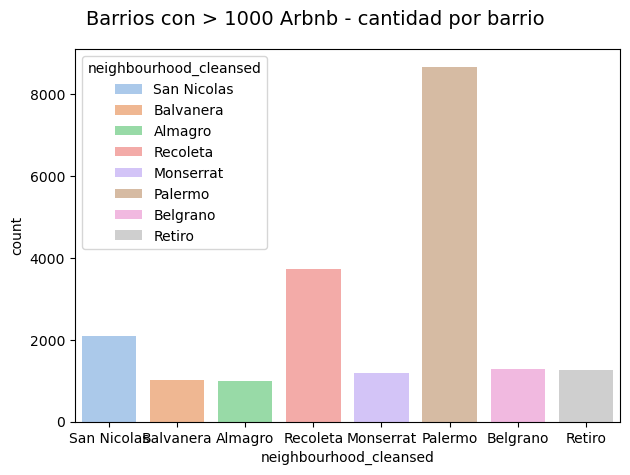

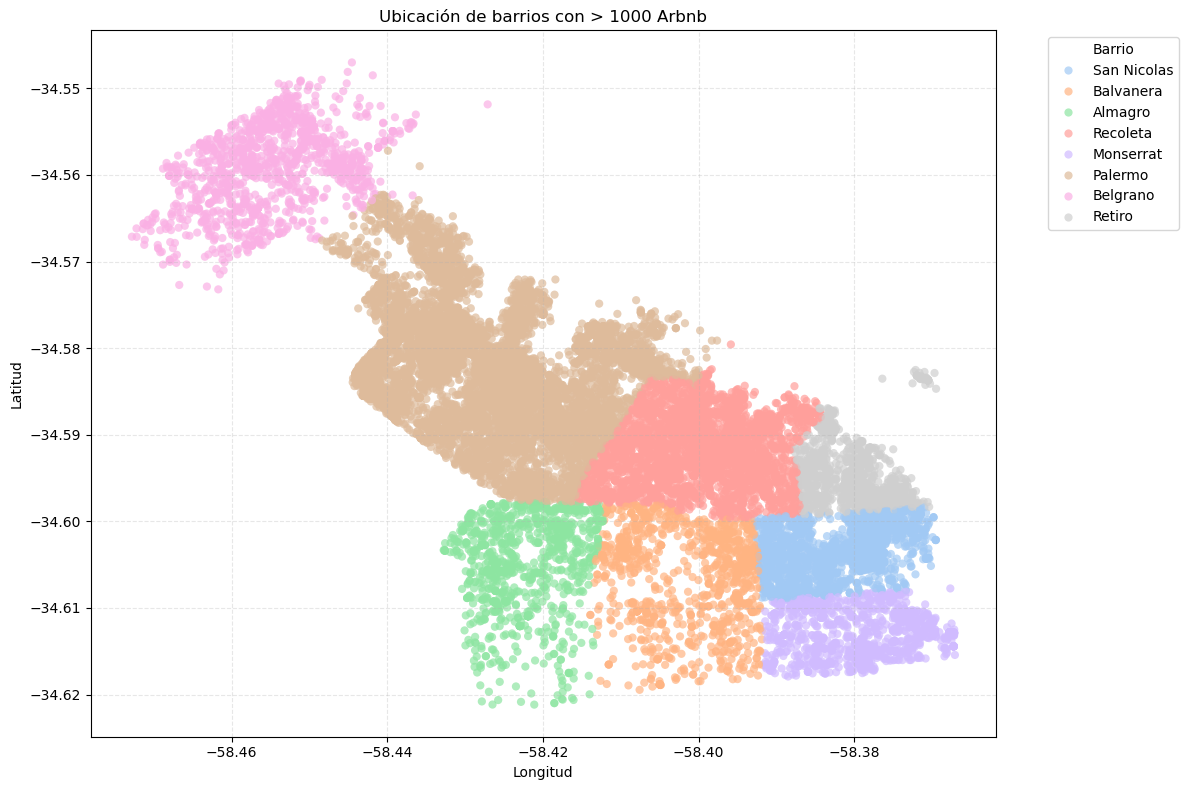

In [174]:
sns.countplot(x="neighbourhood_cleansed", data=top_barrios_df, hue="neighbourhood_cleansed", palette='pastel', legend='brief')

plt.suptitle('Barrios con > 1000 Arbnb - cantidad por barrio', fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
sns.scatterplot(data=top_barrios_df, x='longitude', y='latitude', hue='neighbourhood_cleansed', palette='pastel', alpha=0.7, s=35, edgecolor='none')
plt.title('Ubicación de barrios con > 1000 Arbnb')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Barrio')
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

In [175]:
df4_1.describe()

,id,host_id,hosts_time_as_user_months,hosts_time_as_host_months,host_is_superhost,host_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,availability_60,number_of_reviews_ltm,review_scores_rating,review_scores_location,coffee,wifi,parking,air_conditioning,pool,gym
count,2.650600e+04,2.650600e+04,26506.000000,26506.000000,26506.000000,26506.000000,26506.000000,26506.000000,26506.000000,26506.000000,26450.000000,26506.000000,26409.000000,26409.000000,26506.000000,26506.000000,23360.000000,23360.000000,26506.000000,26506.000000,26506.000000,26506.000000,26506.000000,26506.000000
mean,8.510631e+17,2.359679e+08,92.741568,67.079529,0.422508,17.296386,-34.592026,-58.416400,2.958575,1.234645,1.170586,1.953407,4.788065,588.877807,33.835622,12.206406,4.781500,4.872533,0.654229,0.991926,0.572248,0.680676,0.266996,0.127254
std,5.501088e+17,2.227466e+08,47.664331,47.609669,0.493968,34.627531,0.017948,0.029959,1.568874,0.674610,0.911949,1.510817,16.637815,435.266243,20.870458,17.358121,0.354144,0.251174,0.475628,0.089492,0.494762,0.466224,0.442399,0.333264
min,1.150800e+04,1.342600e+04,0.000000,0.000000,0.000000,1.000000,-34.690056,-58.530890,1.000000,0.500000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.490978e+17,3.418584e+07,46.000000,28.000000,0.000000,1.000000,-34.603142,-58.436096,2.000000,1.000000,1.000000,1.000000,1.000000,365.000000,16.000000,1.000000,4.730000,4.850000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,9.803775e+17,1.575153e+08,100.000000,50.000000,0.000000,3.000000,-34.591311,-58.418395,2.000000,1.000000,1.000000,1.000000,2.000000,365.000000,37.000000,5.000000,4.870000,4.940000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
75%,1.294287e+18,4.574482e+08,128.000000,100.000000,1.000000,15.000000,-34.581421,-58.391261,4.000000,1.000000,1.000000,2.000000,3.000000,1125.000000,53.000000,17.000000,4.980000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,1.605545e+18,7.420151e+08,201.000000,180.000000,1.000000,562.000000,-34.535630,-58.355403,16.000000,22.000000,22.000000,40.000000,730.000000,1825.000000,60.000000,329.000000,5.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Vamos a analizar la variable 'host_listings_count' que tiene un valor maximo de 562.

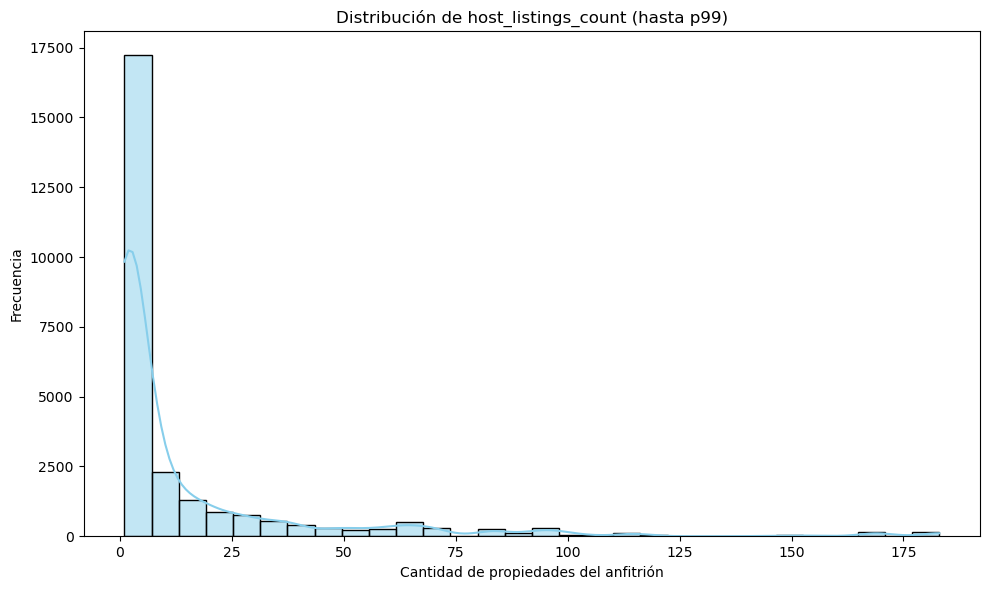

count    26506.000000
mean        17.296386
std         34.627531
min          1.000000
50%          3.000000
75%         15.000000
90%         54.000000
95%         84.000000
99%        183.000000
max        562.000000
Name: host_listings_count, dtype: float64


In [176]:
p99 = df4_1['host_listings_count'].quantile(0.99)
datos = df4_1[df4_1['host_listings_count'] <= p99]['host_listings_count']

plt.figure(figsize=(10, 6))
sns.histplot(datos, bins=30, kde=True, color='skyblue')
plt.title('Distribución de host_listings_count (hasta p99)')
plt.xlabel('Cantidad de propiedades del anfitrión')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

print(df4_1['host_listings_count'].describe(percentiles=[.5, .75, .90, .95, .99]))

por lo que se observa hay un 1% de valores entre 183 y 562, son valores grandes pero no atipicos. Posiblemente sean empresas que manejan alojamientos y posiblemente tengan varios alojamientos superhost

In [177]:
df4_1.describe()

,id,host_id,hosts_time_as_user_months,hosts_time_as_host_months,host_is_superhost,host_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,availability_60,number_of_reviews_ltm,review_scores_rating,review_scores_location,coffee,wifi,parking,air_conditioning,pool,gym
count,2.650600e+04,2.650600e+04,26506.000000,26506.000000,26506.000000,26506.000000,26506.000000,26506.000000,26506.000000,26506.000000,26450.000000,26506.000000,26409.000000,26409.000000,26506.000000,26506.000000,23360.000000,23360.000000,26506.000000,26506.000000,26506.000000,26506.000000,26506.000000,26506.000000
mean,8.510631e+17,2.359679e+08,92.741568,67.079529,0.422508,17.296386,-34.592026,-58.416400,2.958575,1.234645,1.170586,1.953407,4.788065,588.877807,33.835622,12.206406,4.781500,4.872533,0.654229,0.991926,0.572248,0.680676,0.266996,0.127254
std,5.501088e+17,2.227466e+08,47.664331,47.609669,0.493968,34.627531,0.017948,0.029959,1.568874,0.674610,0.911949,1.510817,16.637815,435.266243,20.870458,17.358121,0.354144,0.251174,0.475628,0.089492,0.494762,0.466224,0.442399,0.333264
min,1.150800e+04,1.342600e+04,0.000000,0.000000,0.000000,1.000000,-34.690056,-58.530890,1.000000,0.500000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.490978e+17,3.418584e+07,46.000000,28.000000,0.000000,1.000000,-34.603142,-58.436096,2.000000,1.000000,1.000000,1.000000,1.000000,365.000000,16.000000,1.000000,4.730000,4.850000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,9.803775e+17,1.575153e+08,100.000000,50.000000,0.000000,3.000000,-34.591311,-58.418395,2.000000,1.000000,1.000000,1.000000,2.000000,365.000000,37.000000,5.000000,4.870000,4.940000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
75%,1.294287e+18,4.574482e+08,128.000000,100.000000,1.000000,15.000000,-34.581421,-58.391261,4.000000,1.000000,1.000000,2.000000,3.000000,1125.000000,53.000000,17.000000,4.980000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,1.605545e+18,7.420151e+08,201.000000,180.000000,1.000000,562.000000,-34.535630,-58.355403,16.000000,22.000000,22.000000,40.000000,730.000000,1825.000000,60.000000,329.000000,5.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Analizamos los barrios con mayor cantidad de reviews

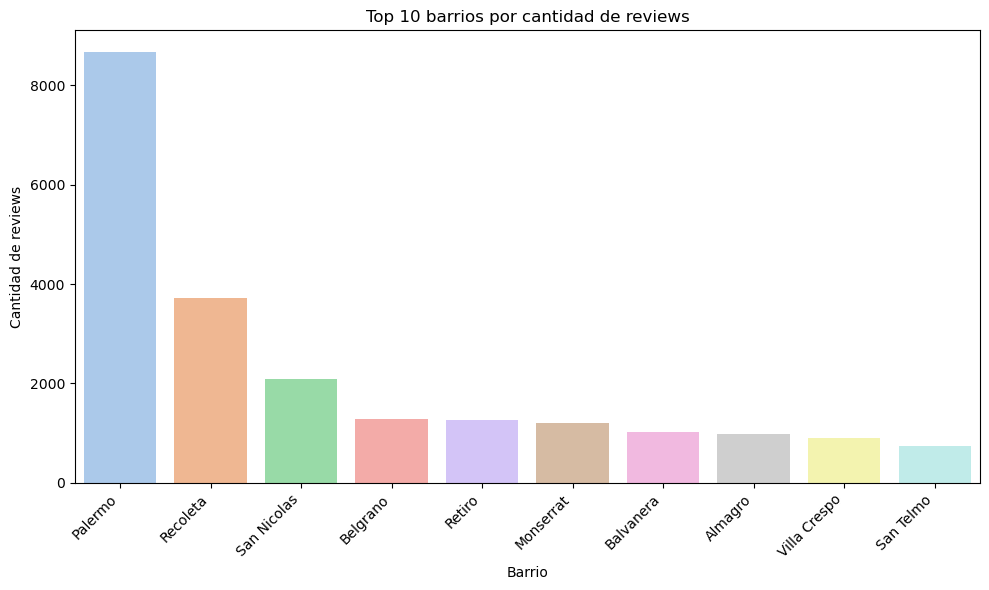

In [178]:
barrios_max = df4_1.groupby('neighbourhood_cleansed')["number_of_reviews_ltm"].count().sort_values(ascending=False).head(10)
top = barrios_max.reset_index(name='count')

plt.figure(figsize=(10,6))
sns.barplot(data=top, x='neighbourhood_cleansed', y='count', palette='pastel', 
            hue='neighbourhood_cleansed', legend=False, order=top['neighbourhood_cleansed'])
plt.title('Top 10 barrios por cantidad de reviews')
plt.xlabel('Barrio')
plt.ylabel('Cantidad de reviews')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Verificamos que barrios tienen mas disponibilidad

<Axes: xlabel='availability_60', ylabel='neighbourhood_cleansed'>

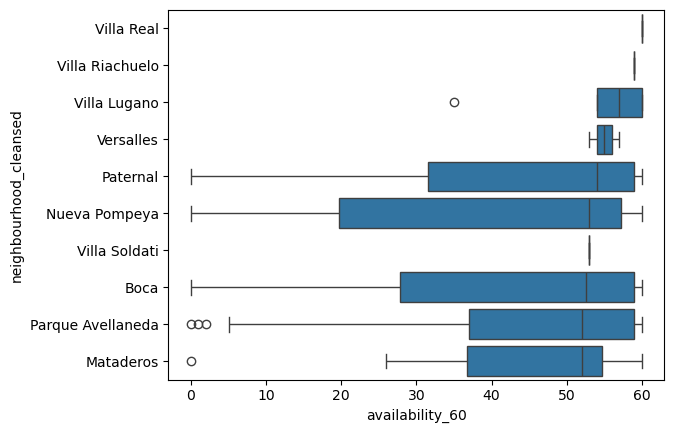

In [179]:
orden = df4_1.groupby('neighbourhood_cleansed')['availability_60'].median().sort_values(ascending=False).head(10).index
sns.boxplot(data=df4_1[df4_1['neighbourhood_cleansed'].isin(orden)], x='availability_60', y='neighbourhood_cleansed', order=orden)

## esto vamoa hacerlo por OHE despues del split yo tengo un csv con las comunas y ahi lo reducimos a 14 variable y lee podemos hacer un OHE

Nos quedamos con los top 5 barrios y creamos atributos categoricos binarios para cada uno

In [180]:
#df4_1["Palermo"] = df4_1["neighbourhood_cleansed"].str.contains("Palermo", case=False, na=False).astype(int)
#df4_1["Recoleta"] = df4_1["neighbourhood_cleansed"].str.contains("Recoleta", case=False, na=False).astype(int)
#df4_1["San Nicolas"] = df4_1["neighbourhood_cleansed"].str.contains("San Nicolas", case=False, na=False).astype(int)
#df4_1["Belgrano"] = df4_1["neighbourhood_cleansed"].str.contains("Belgrano", case=False, na=False).astype(int)
#df4_1["Retiro"] = df4_1["neighbourhood_cleansed"].str.contains("Retiro", case=False, na=False).astype(int)
#df4_2 = df4_1.drop(columns=['neighbourhood_cleansed']).copy()
#df4_2.head()


In [181]:
df4_2 = df4_1

Grafico de disponibilidad

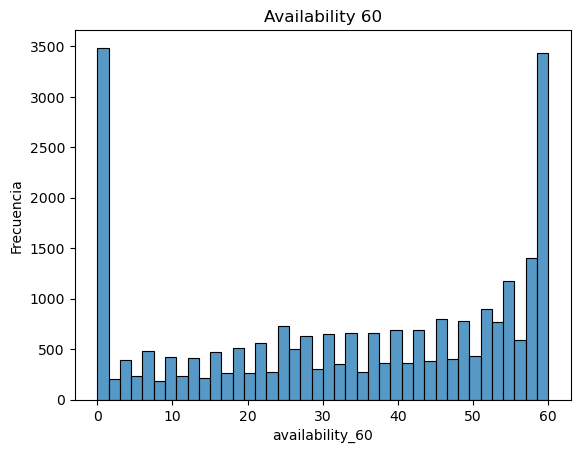

In [182]:
sns.histplot(df4_2["availability_60"].dropna(), bins=40)
plt.title("Availability 60")
plt.xlabel("availability_60")
plt.ylabel("Frecuencia")
plt.show()

Cantidad de reviews vs disponibilidad

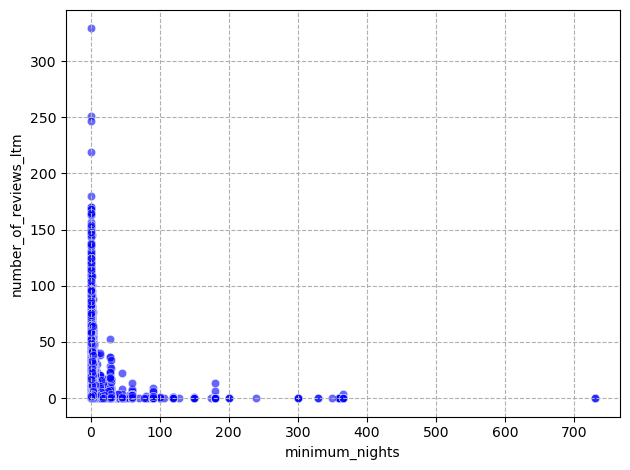

In [183]:
sns.scatterplot(data=df4_2, x='minimum_nights', y='number_of_reviews_ltm', color='b',alpha=0.6)
	
plt.grid(ls='--')
plt.title('')
plt.tight_layout()
plt.show()

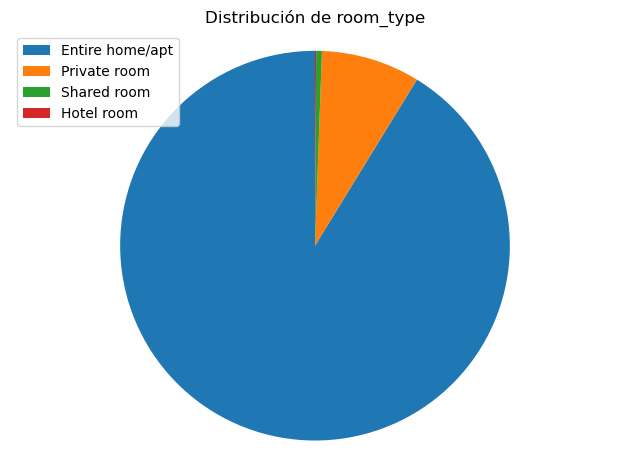

In [184]:
#plot_pie(Airbnb_df, "property_type")
top10 = df4_2["room_type"].value_counts().head(4).index
plot_prop_type = df4_2[df4_2["room_type"].isin(top10)]
colores = [
    "#1f77b4",  # blue
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    "#d62728",  # red
    
]

labels = plot_prop_type["room_type"].value_counts().index
patches, texts = plt.pie(plot_prop_type["room_type"].value_counts(), colors=colores, startangle=90)
plt.title(f'Distribución de room_type')
plt.legend(patches, labels, loc="best")
# Set aspect ratio to be equal so that pie is drawn as a circle.
plt.axis('equal')
plt.tight_layout()
plt.show()

In [185]:
df4_2.describe()

,id,host_id,hosts_time_as_user_months,hosts_time_as_host_months,host_is_superhost,host_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,availability_60,number_of_reviews_ltm,review_scores_rating,review_scores_location,coffee,wifi,parking,air_conditioning,pool,gym
count,2.650600e+04,2.650600e+04,26506.000000,26506.000000,26506.000000,26506.000000,26506.000000,26506.000000,26506.000000,26506.000000,26450.000000,26506.000000,26409.000000,26409.000000,26506.000000,26506.000000,23360.000000,23360.000000,26506.000000,26506.000000,26506.000000,26506.000000,26506.000000,26506.000000
mean,8.510631e+17,2.359679e+08,92.741568,67.079529,0.422508,17.296386,-34.592026,-58.416400,2.958575,1.234645,1.170586,1.953407,4.788065,588.877807,33.835622,12.206406,4.781500,4.872533,0.654229,0.991926,0.572248,0.680676,0.266996,0.127254
std,5.501088e+17,2.227466e+08,47.664331,47.609669,0.493968,34.627531,0.017948,0.029959,1.568874,0.674610,0.911949,1.510817,16.637815,435.266243,20.870458,17.358121,0.354144,0.251174,0.475628,0.089492,0.494762,0.466224,0.442399,0.333264
min,1.150800e+04,1.342600e+04,0.000000,0.000000,0.000000,1.000000,-34.690056,-58.530890,1.000000,0.500000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.490978e+17,3.418584e+07,46.000000,28.000000,0.000000,1.000000,-34.603142,-58.436096,2.000000,1.000000,1.000000,1.000000,1.000000,365.000000,16.000000,1.000000,4.730000,4.850000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,9.803775e+17,1.575153e+08,100.000000,50.000000,0.000000,3.000000,-34.591311,-58.418395,2.000000,1.000000,1.000000,1.000000,2.000000,365.000000,37.000000,5.000000,4.870000,4.940000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
75%,1.294287e+18,4.574482e+08,128.000000,100.000000,1.000000,15.000000,-34.581421,-58.391261,4.000000,1.000000,1.000000,2.000000,3.000000,1125.000000,53.000000,17.000000,4.980000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,1.605545e+18,7.420151e+08,201.000000,180.000000,1.000000,562.000000,-34.535630,-58.355403,16.000000,22.000000,22.000000,40.000000,730.000000,1825.000000,60.000000,329.000000,5.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Analizamos la distribucion de las variables

=== TABLA DE PERCENTILES ===

--- hosts_time_as_user_months ---
count    26506.000000
mean        92.741568
std         47.664331
min          0.000000
25%         46.000000
50%        100.000000
75%        128.000000
90%        154.000000
95%        165.000000
99%        178.950000
max        201.000000
Name: hosts_time_as_user_months, dtype: float64

--- hosts_time_as_host_months ---
count    26506.000000
mean        67.079529
std         47.609669
min          0.000000
25%         28.000000
50%         50.000000
75%        100.000000
90%        142.000000
95%        158.000000
99%        175.000000
max        180.000000
Name: hosts_time_as_host_months, dtype: float64

--- host_listings_count ---
count    26506.000000
mean        17.296386
std         34.627531
min          1.000000
25%          1.000000
50%          3.000000
75%         15.000000
90%         54.000000
95%         84.000000
99%        183.000000
max        562.000000
Name: host_listings_count, dtype: float64

--- acc

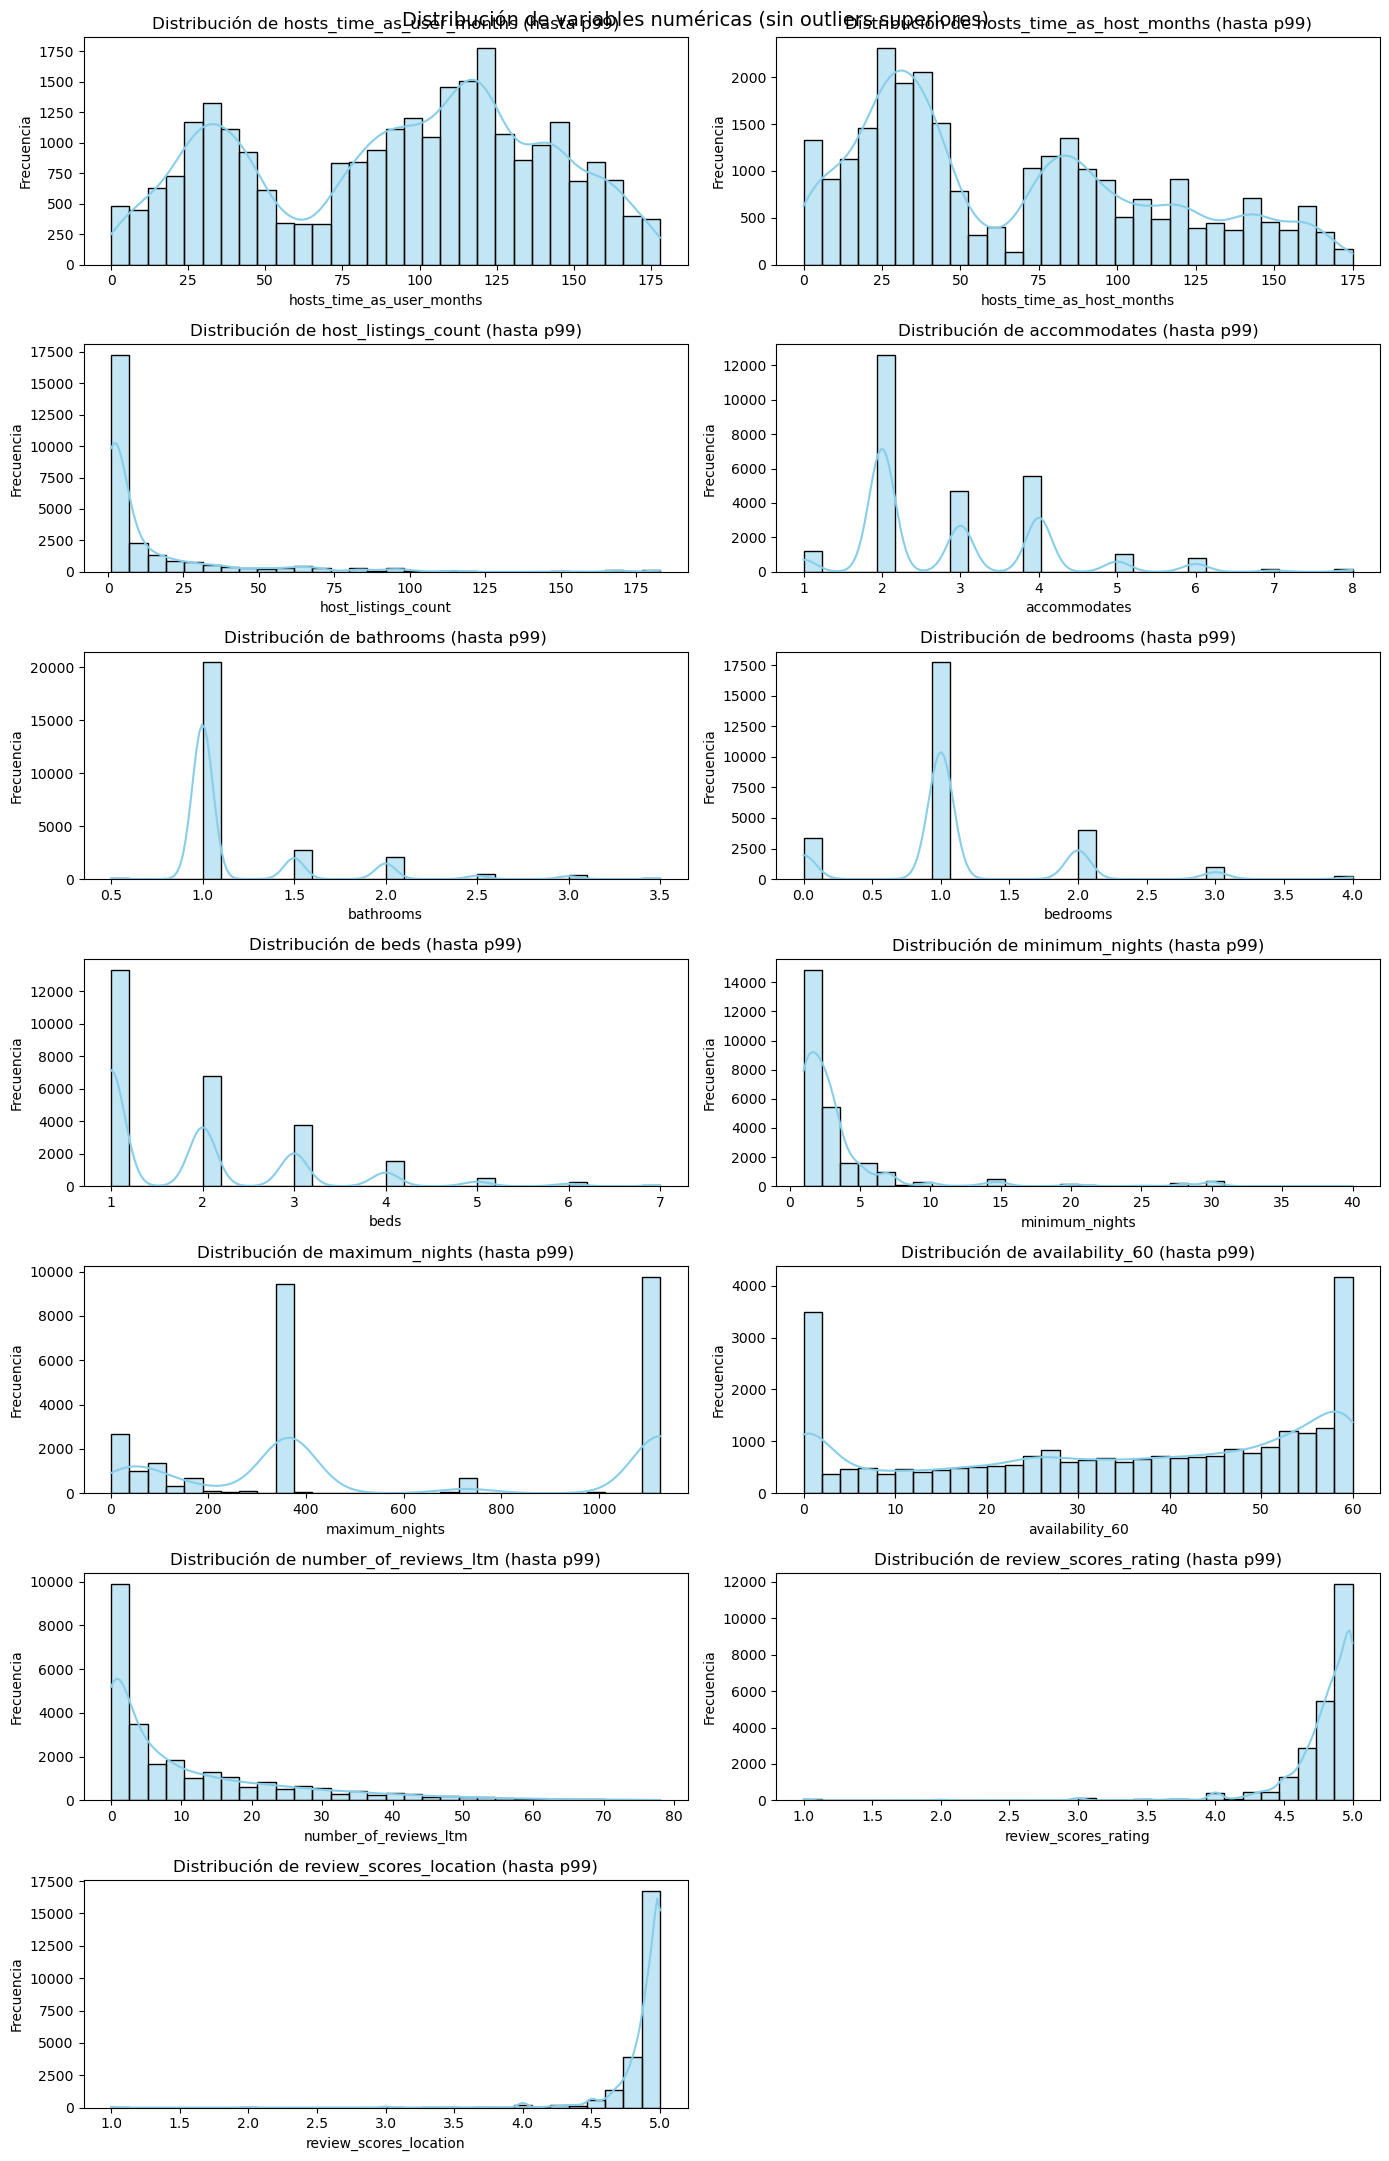

In [186]:
variables = ['hosts_time_as_user_months', 'hosts_time_as_host_months', 
              'host_listings_count', 'accommodates', 'bathrooms', 'bedrooms', 
              'beds', 'minimum_nights', 'maximum_nights', 'availability_60', 
              'number_of_reviews_ltm', 'review_scores_rating', 'review_scores_location']

print("=== TABLA DE PERCENTILES ===\n")
for var in variables:
    print(f"--- {var} ---")
    print(df4_2[var].describe(percentiles=[.25, .50, .75, .90, .95, .99]))
    print()

# Histogramas recortados por p99
fig, axes = plt.subplots(7, 2, figsize=(14, 22))
axes = axes.flatten()

for i, var in enumerate(variables):
    p99 = df4_2[var].quantile(0.99)
    datos = df4_2[df4_2[var] <= p99][var].dropna()
    
    sns.histplot(datos, bins=30, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribución de {var} (hasta p99)')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia')

# Ocultar el último subplot vacío (13 variables en grilla de 14)
axes[-1].set_visible(False)

plt.suptitle('Distribución de variables numéricas (sin outliers superiores)', fontsize=14)
plt.tight_layout()
plt.show()

* Se analizan todas las variables y no hay nada atipico que reportar


Disponibilidad dependiendo del tipo de alojamiento

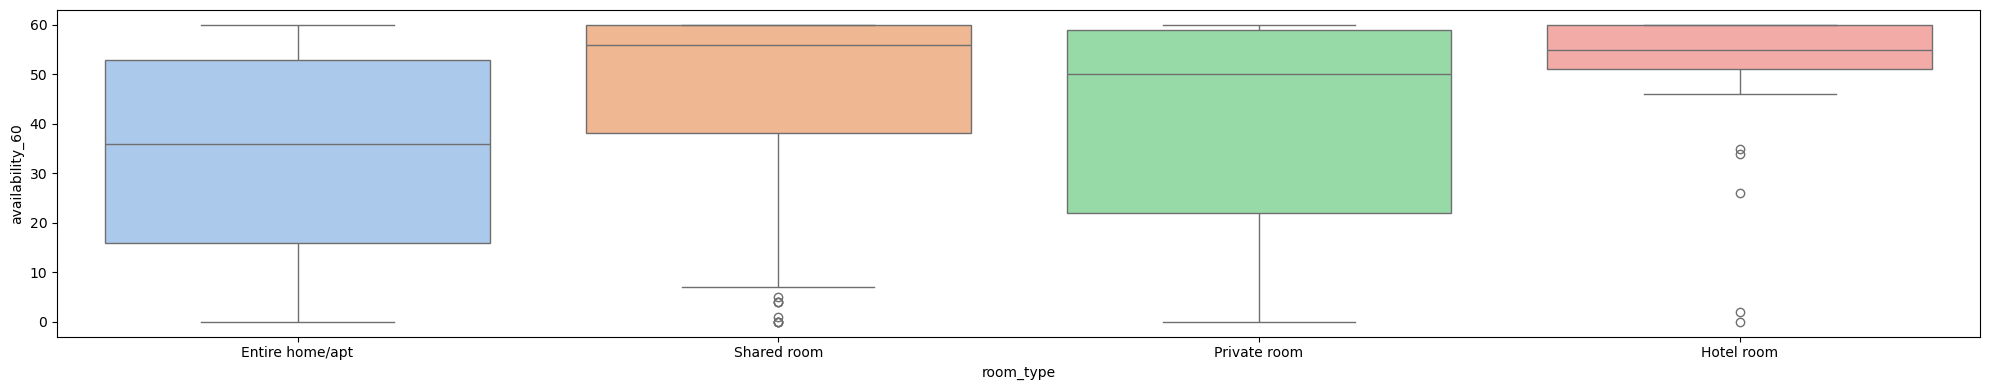

In [187]:
plt.figure(figsize=(20, 4))
sns.boxplot(data=plot_prop_type, x='room_type', y='availability_60', 
            hue='room_type', legend=False, palette='pastel')
plt.tight_layout()
plt.show()

Interesante que la experiencia del host como host y como usuario no esta para nada correlacionada con los puntajes de los reviews. Esto es una buena noticia porque como inversores solo podemos elegir en que invertir, pero no podemos comprar tiempo de experiencia
Resulta interesante tambien hecho de que la correlacion mas fuerte de ratings (el puntaje mas importante) es con 'accuracy' y 'value'. Esto se puede interpretar como que los usuarion valoran mucho la exactitud de la descripcion del listing y la relacion calidad-precio (value for money)
Vemos que la cantidad de reviews anuales no esta correlacionada con el puntaje. Podemos estudiar si la cantidad de propiedades de un host esta relacionada con el puntaje, o sea si el host 'aprende' con la experiencia. Para esto repetimos el ejercicio con los atributos relevantes

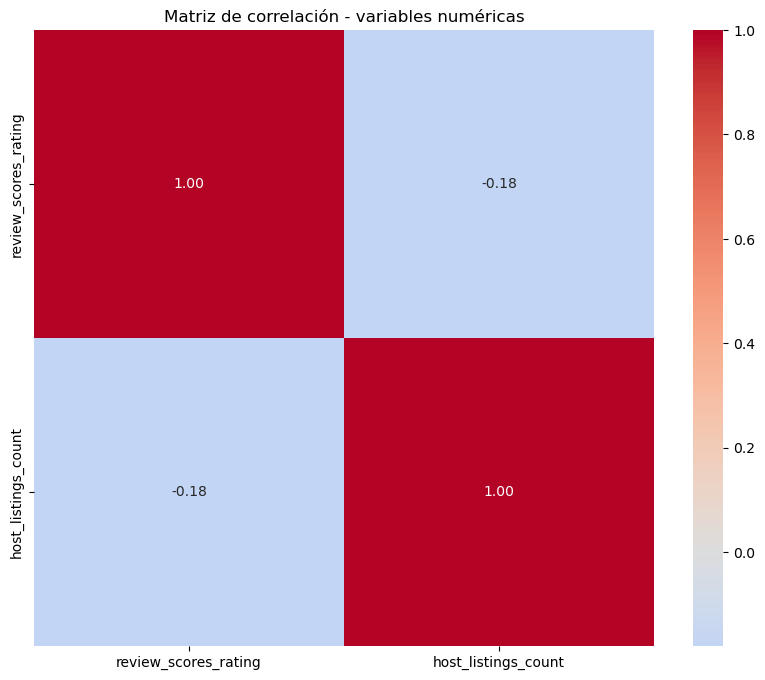

In [188]:
variables = ['review_scores_rating', 'host_listings_count']
corr = df4_2[variables].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación - variables numéricas")
plt.show()

* Vemos que no hay correlacion relevante
* Y que ocurre con la relacion entre los amenities y el puntaje? Estamos buscando correlacion entre un feature categorico binario y uno numerico -> punto biserial

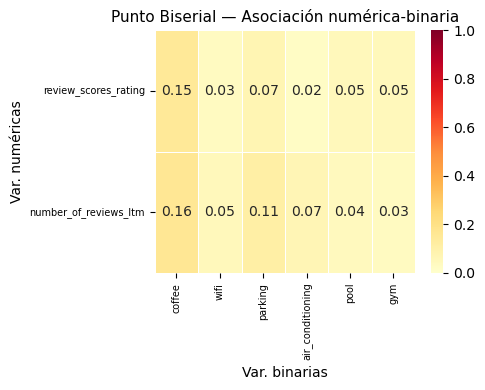

In [189]:
num_cols    = ['review_scores_rating', 'number_of_reviews_ltm']
binarias = ['coffee',	'wifi',	'parking',	'air_conditioning', 'pool', 'gym']

pb_mat = pd.DataFrame(index=num_cols, columns=binarias, dtype=float)

for num_col in num_cols:
    for bin_col in binarias:
        mask = df4_2[num_col].notna() & df4_2[bin_col].notna()
        num  = df4_2.loc[mask, num_col]
        bn   = df4_2.loc[mask, bin_col]
        r, p = pointbiserialr(bn, num) # pointbiserialr Devuelve r y p-value, pero solo nos interesa r
        pb_mat.loc[num_col, bin_col] = abs(r)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(pb_mat.astype(float), annot=True, fmt=".2f", cmap="YlOrRd",
            vmin=0, vmax=1, linewidths=0.5, ax=ax)

ax.set_title("Punto Biserial — Asociación numérica-binaria", fontsize=11)
ax.set_xlabel("Var. binarias")
ax.set_ylabel("Var. numéricas")
ax.set_xticklabels(ax.get_xticklabels(), fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)
plt.tight_layout()
plt.show()

* Solo hay una correlacion debil entre los puntajes y el atributo cafe, con lo cual seria bueno equipar los AirBnB con caferetas

**Ya tenemos el dataset con los atributos relevantes y el target listo para su procesamiento y limpieza**

Primero estudiamos la distribucion del target

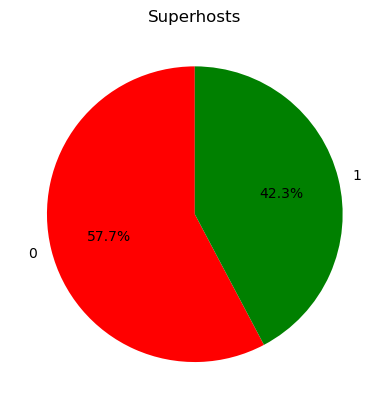

In [190]:
counts = df4_2["host_is_superhost"].value_counts()

color_map = {
    1: "green",
    0: "red"
}

colors = [color_map[v] for v in counts.index]

counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    colors=colors
)

plt.title("Superhosts")
plt.ylabel("")
plt.show()

Venos que es un problema de clasificacion balanceado

In [191]:
df4_2.head()

,id,host_id,hosts_time_as_user_months,hosts_time_as_host_months,host_is_superhost,host_listings_count,host_identity_verified,neighbourhood_cleansed,latitude,longitude,room_type,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,has_availability,availability_60,number_of_reviews_ltm,review_scores_rating,review_scores_location,coffee,wifi,parking,air_conditioning,pool,gym
0,42610838,224049389,86,71,1,3,t,San Nicolas,-34.599976,-58.374195,Entire home/apt,2,1.0,1.0,1.0,7.0,365.0,t,35,0,NaN,NaN,0,1,0,1,0,0
1,1305876403852901802,25649070,132,43,0,1,t,San Nicolas,-34.600382,-58.372692,Entire home/apt,2,1.0,1.0,1.0,2.0,365.0,t,16,0,3.00,5.00,0,1,1,1,0,0
2,1542233033640525302,153014015,99,94,0,1,t,Balvanera,-34.603295,-58.409527,Entire home/apt,2,1.0,1.0,2.0,7.0,365.0,t,21,0,NaN,NaN,0,1,0,1,0,0
3,1004530078359434134,1409800,170,169,0,48,t,Balvanera,-34.599230,-58.407060,Entire home/apt,2,1.0,1.0,1.0,1.0,365.0,t,60,3,4.73,4.59,0,1,0,1,0,0
4,800145927121871422,467965425,42,32,0,2,t,Almagro,-34.599767,-58.426499,Entire home/apt,4,1.0,2.0,3.0,1.0,365.0,NaN,60,0,NaN,NaN,0,1,1,1,1,0


In [192]:
df4_2.shape

(26506, 28)

#### Vamos a realizar el train_test_split

In [193]:
y = df4_2['host_is_superhost']
X = df4_2.drop(columns=['host_is_superhost']).copy()

Verificamos filas y columnas de X e y

In [194]:
X.shape, y.shape

((26506, 27), (26506,))

ahora vamos a realizar el train test split asi podemos realizar todas las traformaciones en el test y luego la aplicamos en el test

In [195]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y )

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (18554, 27)
X_test:  (7952, 27)
y_train: (18554,)
y_test:  (7952,)


#### Ahora vamos a trabajar con  de las variables categoricas

In [196]:
X_train.describe(include='str')

,host_identity_verified,neighbourhood_cleansed,room_type,has_availability
count,18554,18554,18554,18411
unique,2,48,4,1
top,t,Palermo,Entire home/apt,t
freq,18446,6111,16877,18411


Vamos a analizar la variable 'has_availavility' 

In [199]:
X_train['has_availability'].value_counts()

has_availability
t    18411
Name: count, dtype: int64

'has_avalibility' es una variable constnate todo los valores son True por lo tanto no aporta valor y la vamos a eliminar

In [200]:
X_train=X_train.drop(columns=['has_availability']).copy()

Luego seguimos con host_identitiy_verified                      

In [201]:
X_train['host_identity_verified'].value_counts()

host_identity_verified
t    18446
f      108
Name: count, dtype: int64

Tiene varios valores esta variable y parece bastante util, ya que tener la identidad verificada deberia generar confianza en los huespedes.
Entonces vamos a hacer 't'=1 y 'f'= 0

In [202]:
X_train['host_identity_verified'] = X_train['host_identity_verified'].map({'t': 1, 'f': 0})

Ahora avanzamos con la variable 'neighbourhood_cleansed'. vemos que esta variable cuenta con 48 datos distintos, lo que vamos hacer es agruparlos por columnas por lo que nos deberia quedar de solo 14 variables y ahi podemos hacer un OHE

Importo un csv con las comunas

In [203]:
comunas = pd.read_csv(r'C:\Users\Gonzalo Rodriguez\OneDrive\Documentos\Especializacion en IA -CEIA\Analisis de datos\TP\barrios_comunas_caba.csv')

Verificamos que los barrios coincidan

In [204]:
barrios_no_match = set(X_train['neighbourhood_cleansed'].unique()) - set(comunas['barrio'].unique())
print(f"Barrios sin match: {barrios_no_match}")

Barrios sin match: set()


In [205]:
X_train = X_train.merge(comunas, left_on='neighbourhood_cleansed', right_on='barrio', how='left')
X_train = X_train.drop(columns=['neighbourhood_cleansed', 'barrio']).copy()

# Verificar que no quedaron nulos en comuna
print(X_train['comuna'].isnull().sum())
print(X_train.shape)

0
(18554, 26)


Verificamos que nos queda la variable comuna con 15 variables

In [206]:
X_train['comuna'].unique()

array([13,  1, 14,  2,  3, 15,  5,  6, 11, 12,  4, 10,  7,  9,  8])

Vamos  realizar el OHE a la variable 'comuna' y a la variable 'roon_type' ya que vemos que cuenta con solo 4 variables

In [207]:
from sklearn.preprocessing import OneHotEncoder

# Definir columnas a codificar
columnas_ohe = ['comuna', 'room_type']

# Instanciar el encoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')

# Fit y transform en X_train
ohe_train = ohe.fit_transform(X_train[columnas_ohe])

# Crear dataframe con las nuevas columnas
ohe_cols = ohe.get_feature_names_out(columnas_ohe)
ohe_train_df = pd.DataFrame(ohe_train, columns=ohe_cols, index=X_train.index)

# Eliminar columnas originales y agregar las codificadas
X_train = X_train.drop(columns=columnas_ohe)
X_train = pd.concat([X_train, ohe_train_df], axis=1)

In [208]:
X_train.head()

,id,host_id,hosts_time_as_user_months,hosts_time_as_host_months,host_listings_count,host_identity_verified,latitude,longitude,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,availability_60,number_of_reviews_ltm,review_scores_rating,review_scores_location,coffee,wifi,parking,air_conditioning,pool,gym,comuna_2,comuna_3,comuna_4,comuna_5,comuna_6,comuna_7,comuna_8,comuna_9,comuna_10,comuna_11,comuna_12,comuna_13,comuna_14,comuna_15,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,1412212960085352169,114704083,107,8,1,1,-34.549798,-58.450082,2,1.0,1.0,1.0,7.0,40.0,57,2,3.00,4.50,0,1,0,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,1133276629592016393,5027996,102,26,17,1,-34.617205,-58.377452,5,1.0,2.0,3.0,5.0,1125.0,52,9,4.93,4.93,1,1,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,30004682,13040004,97,74,2,1,-34.620504,-58.378614,2,1.0,1.0,1.0,3.0,60.0,30,0,5.00,5.00,0,1,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1104551686559456371,134093644,103,87,38,1,-34.579822,-58.429754,3,1.0,1.0,1.0,1.0,1125.0,22,94,4.77,4.92,0,1,1,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1579733278514758160,447416391,46,1,1,1,-34.586560,-58.414610,6,2.0,3.0,3.0,2.0,120.0,33,4,5.00,5.00,1,1,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


Varificamos con ya no quedan variables categoricas, y se agregaron al final las columnas del OHE.

#### Vamos a verificar los valor nulos que existan

In [209]:
X_train.isnull().sum().sort_values(ascending=False)

review_scores_rating         2195
review_scores_location       2195
maximum_nights                 74
minimum_nights                 74
bedrooms                       42
host_id                         0
hosts_time_as_user_months       0
hosts_time_as_host_months       0
id                              0
accommodates                    0
longitude                       0
latitude                        0
host_identity_verified          0
host_listings_count             0
beds                            0
availability_60                 0
bathrooms                       0
number_of_reviews_ltm           0
coffee                          0
wifi                            0
parking                         0
air_conditioning                0
pool                            0
gym                             0
comuna_2                        0
comuna_3                        0
comuna_4                        0
comuna_5                        0
comuna_6                        0
comuna_7      

Vemos que los valores faltante de review_scores_rating y review_scores_location tienen la misma cantidad y vimos cuando hicimos los anlisis de variable es porque tienen o reviews.

In [210]:
# Verificar que los nulos en review_scores coinciden con 0 reviews
print(X_train[X_train['review_scores_rating'].isnull()]['number_of_reviews_ltm'].describe())

# Ver cuántos tienen 0 reviews en total
print(f"\nTotal con number_of_reviews_ltm == 0: {(X_train['number_of_reviews_ltm'] == 0).sum()}")
print(f"Total con review_scores_rating nulo: {X_train['review_scores_rating'].isnull().sum()}")

count    2195.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: number_of_reviews_ltm, dtype: float64

Total con number_of_reviews_ltm == 0: 4352
Total con review_scores_rating nulo: 2195


Es decir: 100% de los nulos en review_scores corresponden a alojamientos sin reseñas recientes, confirma que el faltante es MAR (Missing At Random, condicionado a otra variable observada: no tener reviews)

Vamos la distribucion de las variables

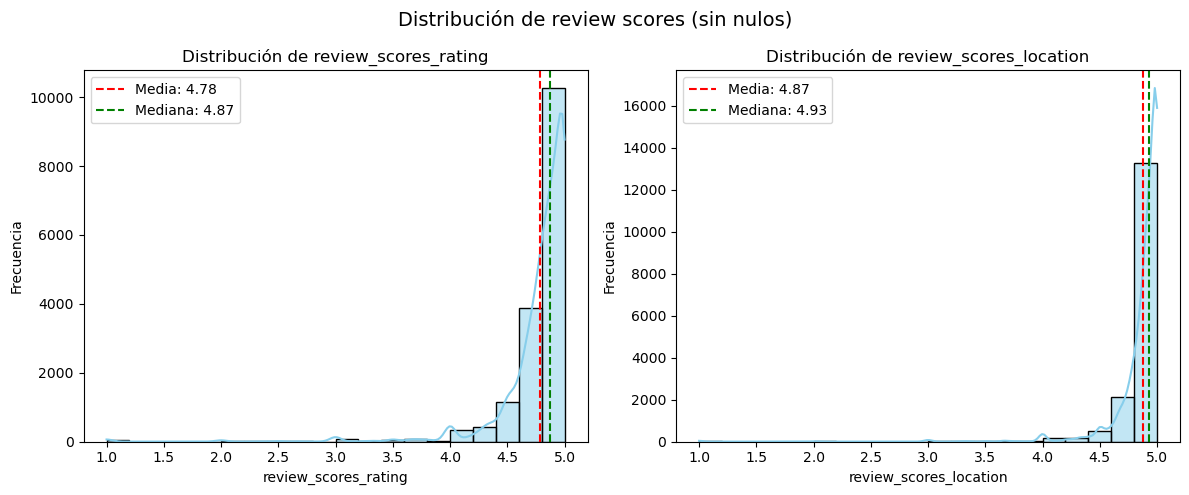

In [211]:
variables = ['review_scores_rating', 'review_scores_location']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, var in enumerate(variables):
    sns.histplot(X_train[var].dropna(), bins=20, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribución de {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia')
    
    # Líneas de media y mediana
    media = X_train[var].mean()
    mediana = X_train[var].median()
    axes[i].axvline(media, color='red', linestyle='--', label=f'Media: {media:.2f}')
    axes[i].axvline(mediana, color='green', linestyle='--', label=f'Mediana: {mediana:.2f}')
    axes[i].legend()

plt.suptitle('Distribución de review scores (sin nulos)', fontsize=14)
plt.tight_layout()
plt.show()

Ambas variables presentan asimetría negativa (cola hacia la izquierda). En distribuciones asimétricas, la media se ve afectada por los valores extremos, 
desplazándose hacia ellos. La mediana, al ser el valor central, representa mejor el comportamiento típico y es más robusta ante estos outliers. Por lo tanto, optamos por imputar con la mediana.

Vamos a analizar las variables 'minimum_nights', 'maximum_nights' que tienen la misma cantida de ausentes

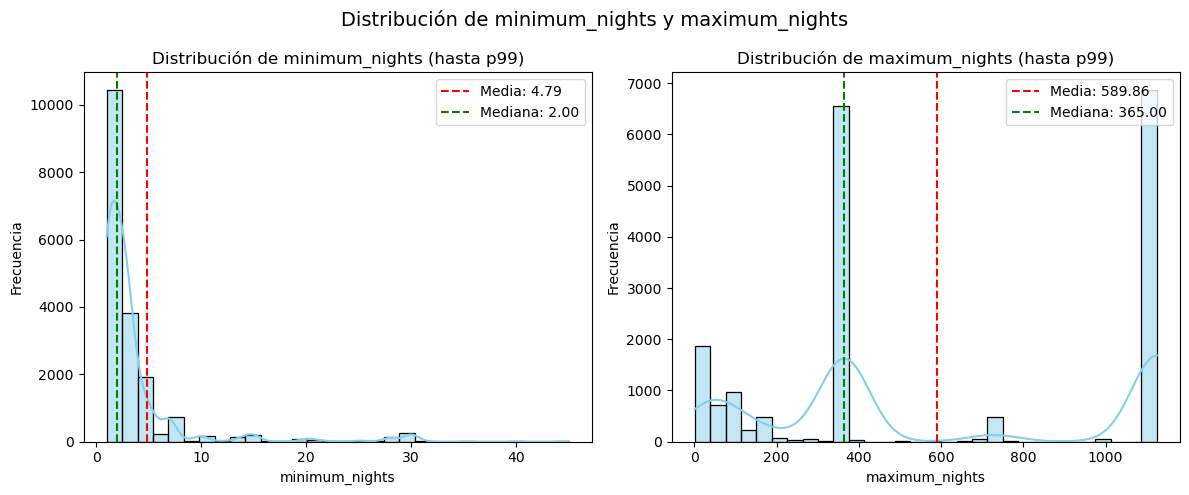

In [212]:
variables = ['minimum_nights', 'maximum_nights']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, var in enumerate(variables):
    p99 = X_train[var].quantile(0.99)
    datos = X_train[X_train[var] <= p99][var].dropna()
    
    sns.histplot(datos, bins=30, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribución de {var} (hasta p99)')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia')
    
    media = X_train[var].mean()
    mediana = X_train[var].median()
    axes[i].axvline(media, color='red', linestyle='--', label=f'Media: {media:.2f}')
    axes[i].axvline(mediana, color='green', linestyle='--', label=f'Mediana: {mediana:.2f}')
    axes[i].legend()

plt.suptitle('Distribución de minimum_nights y maximum_nights', fontsize=14)
plt.tight_layout()
plt.show()

Vemos comportamientos distintos de la distribucion. En 'minimum_nights' se ve una distribucion asimetrica con cola hacia la derecha entonces para imputar con el menor impacto en la distribucion lo hacemos con la mediana que vemos cae donde esta la mayor poblacion. 
En el caso del 'maximum_nights' es una distgribucion multimodal con varios picos, asi que si imputamos la mediana vemos que cae en el pico mas pronunciado que es 365 que debe ser el valor mas estandar que se pone por defecto.
Conclusion en ambos graficos hay que imputar con la mediana.

Ahora analicemos la ultima que nos falta que seria bedrooms

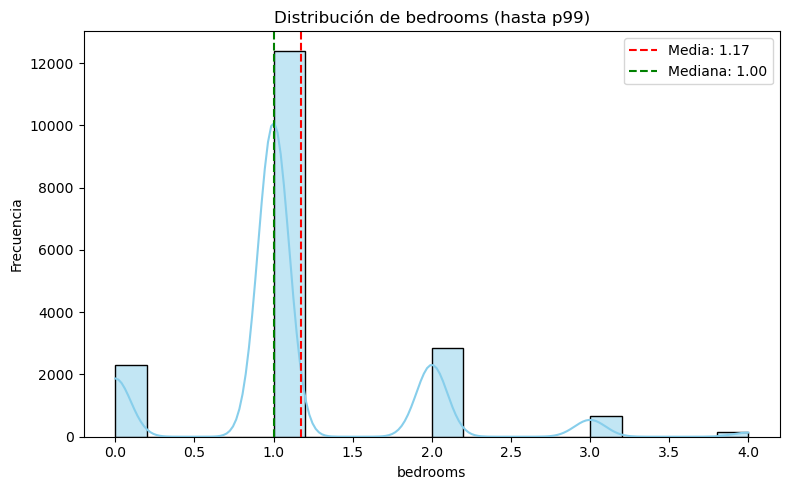

In [213]:
p99 = X_train['bedrooms'].quantile(0.99)
datos = X_train[X_train['bedrooms'] <= p99]['bedrooms'].dropna()

plt.figure(figsize=(8, 5))
sns.histplot(datos, bins=20, kde=True, color='skyblue')

media = X_train['bedrooms'].mean()
mediana = X_train['bedrooms'].median()
plt.axvline(media, color='red', linestyle='--', label=f'Media: {media:.2f}')
plt.axvline(mediana, color='green', linestyle='--', label=f'Mediana: {mediana:.2f}')
plt.legend()

plt.title('Distribución de bedrooms (hasta p99)')
plt.xlabel('bedrooms')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

Mismo patro y conclusiones tomadas para maximum_night. PAtron multimodal y vamos a imputar por la mediana que es quien menos nos altera la destribucion de la variable.

Concluimos que todas las variables se imputan por la mediana

In [214]:
from sklearn.impute import SimpleImputer

columnas_imputar = ['review_scores_rating', 'review_scores_location', 
                     'minimum_nights', 'maximum_nights', 'bedrooms']

imputer = SimpleImputer(strategy='median')

X_train[columnas_imputar] = imputer.fit_transform(X_train[columnas_imputar])

print(X_train[columnas_imputar].isnull().sum())

review_scores_rating      0
review_scores_location    0
minimum_nights            0
maximum_nights            0
bedrooms                  0
dtype: int64


Por ultimo corroboramos que no hay mas valores ausentes.

#### Analicemos si existen outliers

In [215]:
X_train.describe()

,id,host_id,hosts_time_as_user_months,hosts_time_as_host_months,host_listings_count,host_identity_verified,latitude,longitude,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,availability_60,number_of_reviews_ltm,review_scores_rating,review_scores_location,coffee,wifi,parking,air_conditioning,pool,gym,comuna_2,comuna_3,comuna_4,comuna_5,comuna_6,comuna_7,comuna_8,comuna_9,comuna_10,comuna_11,comuna_12,comuna_13,comuna_14,comuna_15,room_type_Hotel room,room_type_Private room,room_type_Shared room
count,1.855400e+04,1.855400e+04,18554.000000,18554.000000,18554.000000,18554.000000,18554.000000,18554.000000,18554.000000,18554.000000,18554.000000,18554.000000,18554.000000,18554.000000,18554.000000,18554.000000,18554.000000,18554.000000,18554.000000,18554.000000,18554.000000,18554.000000,18554.000000,18554.000000,18554.000000,18554.000000,18554.000000,18554.000000,18554.000000,18554.000000,18554.000000,18554.000000,18554.000000,18554.000000,18554.000000,18554.000000,18554.000000,18554.000000,18554.000000,18554.000000,18554.000000
mean,8.476726e+17,2.349501e+08,92.942600,67.140886,17.037404,0.994179,-34.592017,-58.416412,2.964482,1.236283,1.173170,1.956721,4.775628,588.963027,33.813625,12.235744,4.792679,4.880926,0.651073,0.991915,0.571683,0.680608,0.267328,0.126927,0.139862,0.044896,0.014229,0.041554,0.015684,0.007168,0.000323,0.002264,0.003934,0.008085,0.023176,0.086558,0.329363,0.057184,0.000862,0.084672,0.004851
std,5.508419e+17,2.222839e+08,47.540442,47.505448,34.223918,0.076074,0.017983,0.029900,1.565329,0.670108,0.895457,1.470716,16.925293,435.515614,20.894586,17.318739,0.327206,0.221818,0.476644,0.089552,0.494848,0.466254,0.442577,0.332900,0.346853,0.207081,0.118436,0.199574,0.124253,0.084364,0.017980,0.047525,0.062603,0.089552,0.150465,0.281194,0.469995,0.232201,0.029354,0.278400,0.069480
min,1.385100e+04,1.342600e+04,0.000000,0.000000,1.000000,0.000000,-34.690056,-58.530890,1.000000,0.500000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.433945e+07,3.425592e+07,46.000000,28.000000,1.000000,1.000000,-34.603079,-58.435980,2.000000,1.000000,1.000000,1.000000,1.000000,365.000000,16.000000,1.000000,4.750000,4.860000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,9.777724e+17,1.563405e+08,100.000000,50.000000,3.000000,1.000000,-34.591310,-58.418505,2.000000,1.000000,1.000000,1.000000,2.000000,365.000000,37.000000,5.000000,4.870000,4.930000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.292753e+18,4.559822e+08,128.000000,101.000000,15.000000,1.000000,-34.581413,-58.391346,4.000000,1.000000,1.000000,2.000000,3.000000,1125.000000,54.000000,17.000000,4.960000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,1.605434e+18,7.420151e+08,201.000000,180.000000,562.000000,1.000000,-34.535630,-58.355403,16.000000,22.000000,22.000000,30.000000,730.000000,1825.000000,60.000000,329.000000,5.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Vamos analizar alguna variables que pueden taner valores maximas mas llamativos

=== TABLA DE PERCENTILES ===

--- host_listings_count ---
count    18554.000000
mean        17.037404
std         34.223918
min          1.000000
25%          1.000000
50%          3.000000
75%         15.000000
90%         53.000000
95%         84.000000
99%        183.000000
max        562.000000
Name: host_listings_count, dtype: float64

--- bathrooms ---
count    18554.000000
mean         1.236283
std          0.670108
min          0.500000
25%          1.000000
50%          1.000000
75%          1.000000
90%          2.000000
95%          2.000000
99%          3.500000
max         22.000000
Name: bathrooms, dtype: float64

--- bedrooms ---
count    18554.000000
mean         1.173170
std          0.895457
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
90%          2.000000
95%          3.000000
99%          4.000000
max         22.000000
Name: bedrooms, dtype: float64

--- beds ---
count    18554.000000
mean         1.956721
std          1.4

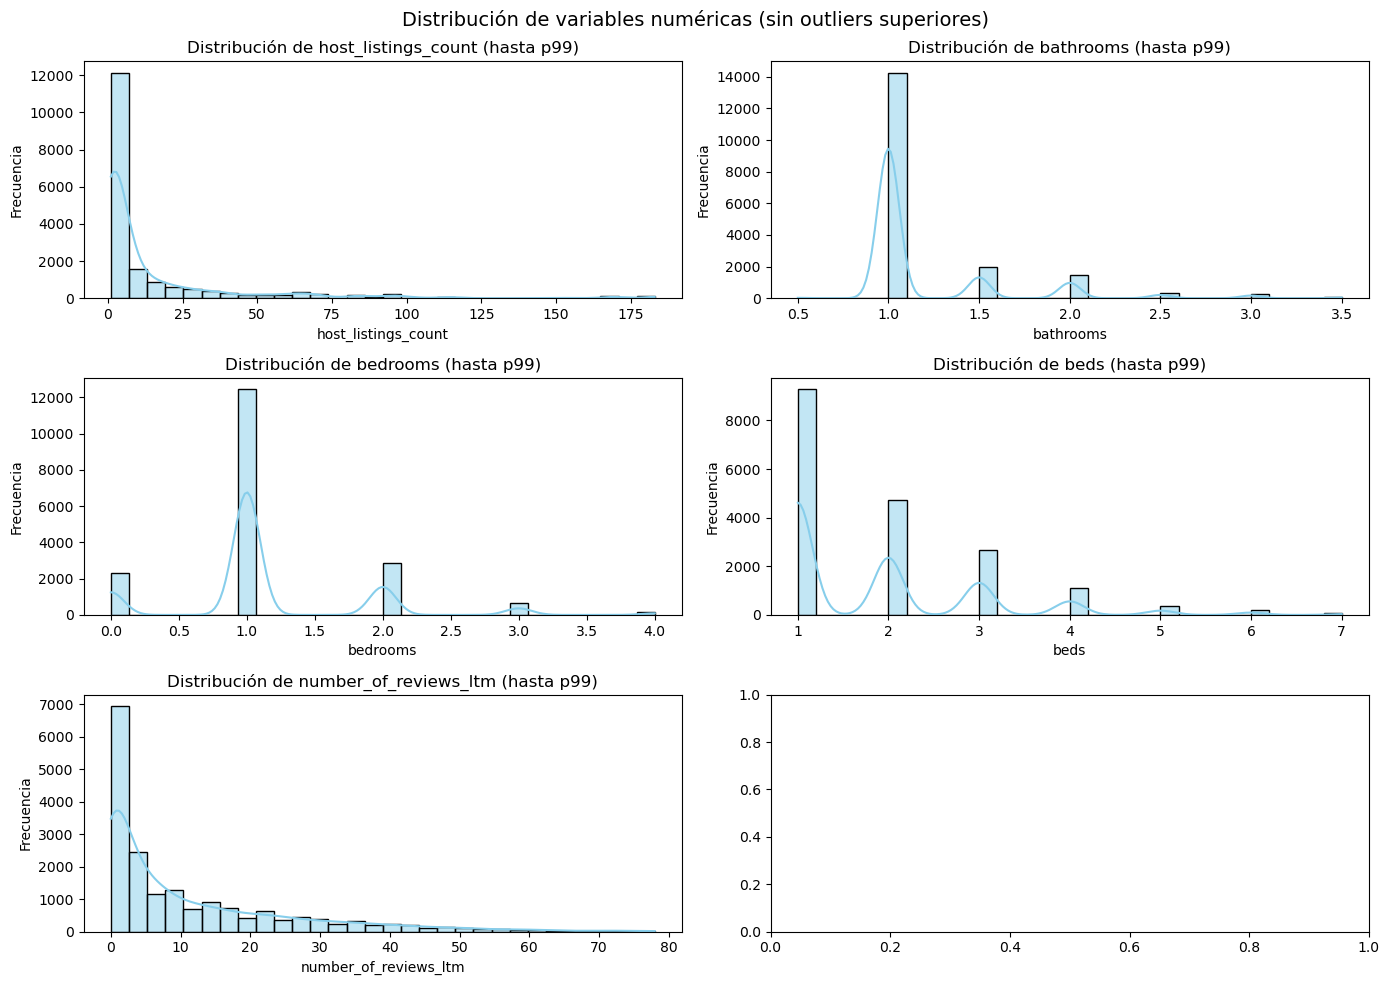

In [216]:
variables = ['host_listings_count', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews_ltm']

# Tabla de percentiles
print("=== TABLA DE PERCENTILES ===\n")
for var in variables:
    print(f"--- {var} ---")
    print(X_train[var].describe(percentiles=[.25, .50, .75, .90, .95, .99]))
    print()

# Histogramas recortados por p99
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(variables):
    p99 = X_train[var].quantile(0.99)
    datos = X_train[X_train[var] <= p99][var].dropna()
    
    sns.histplot(datos, bins=30, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribución de {var} (hasta p99)')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de variables numéricas (sin outliers superiores)', fontsize=14)
plt.tight_layout()
plt.show()

Se observa en todas las variables que pueden tener algunos valores altos pero no son atipicos sino de huespedes especiales.
CONCLUSION NO SE ANULA NINGUN DATO POR OUTLIERS

In [217]:
X_train.head()

,id,host_id,hosts_time_as_user_months,hosts_time_as_host_months,host_listings_count,host_identity_verified,latitude,longitude,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,availability_60,number_of_reviews_ltm,review_scores_rating,review_scores_location,coffee,wifi,parking,air_conditioning,pool,gym,comuna_2,comuna_3,comuna_4,comuna_5,comuna_6,comuna_7,comuna_8,comuna_9,comuna_10,comuna_11,comuna_12,comuna_13,comuna_14,comuna_15,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,1412212960085352169,114704083,107,8,1,1,-34.549798,-58.450082,2,1.0,1.0,1.0,7.0,40.0,57,2,3.00,4.50,0,1,0,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,1133276629592016393,5027996,102,26,17,1,-34.617205,-58.377452,5,1.0,2.0,3.0,5.0,1125.0,52,9,4.93,4.93,1,1,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,30004682,13040004,97,74,2,1,-34.620504,-58.378614,2,1.0,1.0,1.0,3.0,60.0,30,0,5.00,5.00,0,1,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1104551686559456371,134093644,103,87,38,1,-34.579822,-58.429754,3,1.0,1.0,1.0,1.0,1125.0,22,94,4.77,4.92,0,1,1,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1579733278514758160,447416391,46,1,1,1,-34.586560,-58.414610,6,2.0,3.0,3.0,2.0,120.0,33,4,5.00,5.00,1,1,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


Aunque Phi y point-biserial provienen de tradiciones estadísticas distintas (Chi-cuadrado para tablas de contingencia vs. correlación de Pearson), ambas 
se reducen matemáticamente a la misma fórmula cuando las dos variables son binarias (0/1) — Phi es simplemente Pearson aplicado a ese caso particular. 
Por eso usamos una sola función para calcular la asociación de todas las features (numéricas y binarias) contra el target.

In [218]:
from scipy import stats

def asociacion_con_target(X, y, col):
    valores_unicos = X[col].nunique()
    
    if valores_unicos < 2:
        return {'feature': col, 'tipo': 'constante', 'asociacion': np.nan, 'p_value': np.nan}
    
    try:
        corr, pvalue = stats.pointbiserialr(y, X[col])
    except Exception as e:
        return {'feature': col, 'tipo': 'error', 'asociacion': np.nan, 'p_value': np.nan}
    
    tipo = "Phi (binaria)" if valores_unicos == 2 else "Point-biserial (numerica)"
    
    return {'feature': col, 'tipo': tipo, 'asociacion': corr, 'p_value': pvalue}


resultados = []
for col in X_train.columns:
    if col in ['id', 'host_id']:
        continue
    resultados.append(asociacion_con_target(X_train, y_train, col))

resultados_df = pd.DataFrame(resultados)
resultados_df['asociacion_abs'] = resultados_df['asociacion'].abs()
resultados_df = resultados_df.sort_values('asociacion_abs', ascending=False)


def interpretar_asociacion(row):
    valor = row['asociacion']
    pvalue = row['p_value']
    
    if pd.isna(valor):
        return "no calculable"
    
    if pvalue >= 0.05:
        return "no significativa"
    
    v = abs(valor)
    if v < 0.1:
        return "significativa - débil"
    elif v < 0.3:
        return "significativa - débil-moderada"
    elif v < 0.5:
        return "significativa - moderada-fuerte"
    else:
        return "significativa - fuerte"

resultados_df['interpretacion'] = resultados_df.apply(interpretar_asociacion, axis=1)
print(resultados_df.to_string(index=False))

                  feature                      tipo  asociacion       p_value  asociacion_abs                  interpretacion
    number_of_reviews_ltm Point-biserial (numerica)    0.312721  0.000000e+00        0.312721 significativa - moderada-fuerte
                   coffee             Phi (binaria)    0.232413 5.003853e-226        0.232413  significativa - débil-moderada
     review_scores_rating Point-biserial (numerica)    0.223776 2.885544e-209        0.223776  significativa - débil-moderada
                  parking             Phi (binaria)    0.151833  4.238305e-96        0.151833  significativa - débil-moderada
           maximum_nights Point-biserial (numerica)    0.119688  3.645238e-60        0.119688  significativa - débil-moderada
   review_scores_location Point-biserial (numerica)    0.110502  1.693202e-51        0.110502  significativa - débil-moderada
          availability_60 Point-biserial (numerica)   -0.101070  2.496599e-43        0.101070  significativa - débil-m

Para la selección de features, utilizamos como criterio la **significancia estadística** (p-value < 0.05) de la asociación entre cada feature y el target 
`host_is_superhost`, calculada mediante point-biserial/Phi según corresponda.
A diferencia de filtrar por la magnitud del coeficiente (que descartaría prácticamente todas las variables al ser, en su mayoría, asociaciones débiles), 
este criterio responde a la pregunta de si la asociación observada es estadísticamente distinguible del azar, independientemente de su tamaño

In [219]:
# Filtrar features con asociación estadísticamente significativa (p < 0.05)
seleccionadas = resultados_df[resultados_df['p_value'] < 0.05]['feature'].tolist()
descartadas = resultados_df[resultados_df['p_value'] >= 0.05]['feature'].tolist()

print(f"Variables seleccionadas: {len(seleccionadas)}")
print(seleccionadas)
print(f"\nVariables descartadas (p >= 0.05): {len(descartadas)}")
print(descartadas)

Variables seleccionadas: 30
['number_of_reviews_ltm', 'coffee', 'review_scores_rating', 'parking', 'maximum_nights', 'review_scores_location', 'availability_60', 'gym', 'room_type_Private room', 'hosts_time_as_user_months', 'air_conditioning', 'host_listings_count', 'comuna_14', 'pool', 'minimum_nights', 'accommodates', 'hosts_time_as_host_months', 'wifi', 'comuna_3', 'room_type_Shared room', 'latitude', 'comuna_10', 'comuna_2', 'comuna_6', 'comuna_9', 'comuna_12', 'comuna_11', 'room_type_Hotel room', 'comuna_7', 'comuna_4']

Variables descartadas (p >= 0.05): 9
['comuna_13', 'bedrooms', 'comuna_5', 'beds', 'longitude', 'host_identity_verified', 'comuna_8', 'comuna_15', 'bathrooms']


In [220]:
# Aplicar el filtro a X_train
X_train = X_train[seleccionadas].copy()
print(X_train.shape)

(18554, 30)


In [221]:
X_train.head()

,number_of_reviews_ltm,coffee,review_scores_rating,parking,maximum_nights,review_scores_location,availability_60,gym,room_type_Private room,hosts_time_as_user_months,air_conditioning,host_listings_count,comuna_14,pool,minimum_nights,accommodates,hosts_time_as_host_months,wifi,comuna_3,room_type_Shared room,latitude,comuna_10,comuna_2,comuna_6,comuna_9,comuna_12,comuna_11,room_type_Hotel room,comuna_7,comuna_4
0,2,0,3.00,0,40.0,4.50,57,0,0.0,107,1,1,0.0,0,7.0,2,8,1,0.0,0.0,-34.549798,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,9,1,4.93,1,1125.0,4.93,52,0,0.0,102,1,17,0.0,0,5.0,5,26,1,0.0,0.0,-34.617205,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0,5.00,1,60.0,5.00,30,0,0.0,97,1,2,0.0,0,3.0,2,74,1,0.0,0.0,-34.620504,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,94,0,4.77,1,1125.0,4.92,22,0,0.0,103,1,38,1.0,1,1.0,3,87,1,0.0,0.0,-34.579822,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,1,5.00,1,120.0,5.00,33,0,0.0,46,1,1,1.0,0,2.0,6,1,1,0.0,0.0,-34.586560,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### En el siguiente paso vamos a escalar  los valores

In [222]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)

In [223]:
X_train_scaled.head()

,number_of_reviews_ltm,coffee,review_scores_rating,parking,maximum_nights,review_scores_location,availability_60,gym,room_type_Private room,hosts_time_as_user_months,air_conditioning,host_listings_count,comuna_14,pool,minimum_nights,accommodates,hosts_time_as_host_months,wifi,comuna_3,room_type_Shared room,latitude,comuna_10,comuna_2,comuna_6,comuna_9,comuna_12,comuna_11,room_type_Hotel room,comuna_7,comuna_4
0,-0.591037,-1.365989,-5.478897,-1.155300,-1.260524,-1.717339,1.109713,-0.381286,-0.304145,0.295701,0.685036,-0.468615,-0.700799,-0.604042,0.131427,-0.616169,-1.244962,0.09028,-0.21681,-0.069817,2.347760,-0.062849,-0.403242,-0.126229,-0.047632,-0.154031,-0.09028,-0.029378,-0.084971,-0.120142
1,-0.186840,0.732070,0.419690,0.865576,1.230843,0.221239,0.870410,-0.381286,-0.304145,0.190525,0.685036,-0.001093,-0.700799,-0.604042,0.013257,1.300412,-0.866048,0.09028,-0.21681,-0.069817,-1.400704,-0.062849,-0.403242,-0.126229,-0.047632,-0.154031,-0.09028,-0.029378,-0.084971,-0.120142
2,-0.706522,-1.365989,0.633628,0.865576,-1.214600,0.536822,-0.182522,-0.381286,-0.304145,0.085349,0.685036,-0.439395,-0.700799,-0.604042,-0.104913,-0.616169,0.144390,0.09028,-0.21681,-0.069817,-1.584162,-0.062849,-0.403242,-0.126229,-0.047632,-0.154031,-0.09028,-0.029378,-0.084971,-0.120142
3,4.721271,-1.365989,-0.069312,0.865576,1.230843,0.176156,-0.565407,-0.381286,-0.304145,0.211560,0.685036,0.612530,1.426942,1.655514,-0.223082,0.022691,0.418050,0.09028,-0.21681,-0.069817,0.678148,-0.062849,-0.403242,-0.126229,-0.047632,-0.154031,-0.09028,-0.029378,-0.084971,-0.120142
4,-0.475552,0.732070,0.633628,0.865576,-1.076829,0.536822,-0.038941,-0.381286,-0.304145,-0.987451,0.685036,-0.468615,1.426942,-0.604042,-0.163997,1.939272,-1.392318,0.09028,-0.21681,-0.069817,0.303468,-0.062849,-0.403242,-0.126229,-0.047632,-0.154031,-0.09028,-0.029378,-0.084971,-0.120142


##### La variable target `host_is_superhost` presenta una distribución de 57.7% (0) y 42.3% (1), lo cual representa un dataset prácticamente balanceado. Por lo tanto, 
##### no es necesario aplicar técnicas de balanceo (SMOTE, undersampling, etc.). Adicionalmente, se utilizó `stratify=y` en el train/test split para preservar 
##### esta proporción tanto en el conjunto de entrenamiento como en el de test.

Avanzamos con la reduccion de dimencionalidad PCA

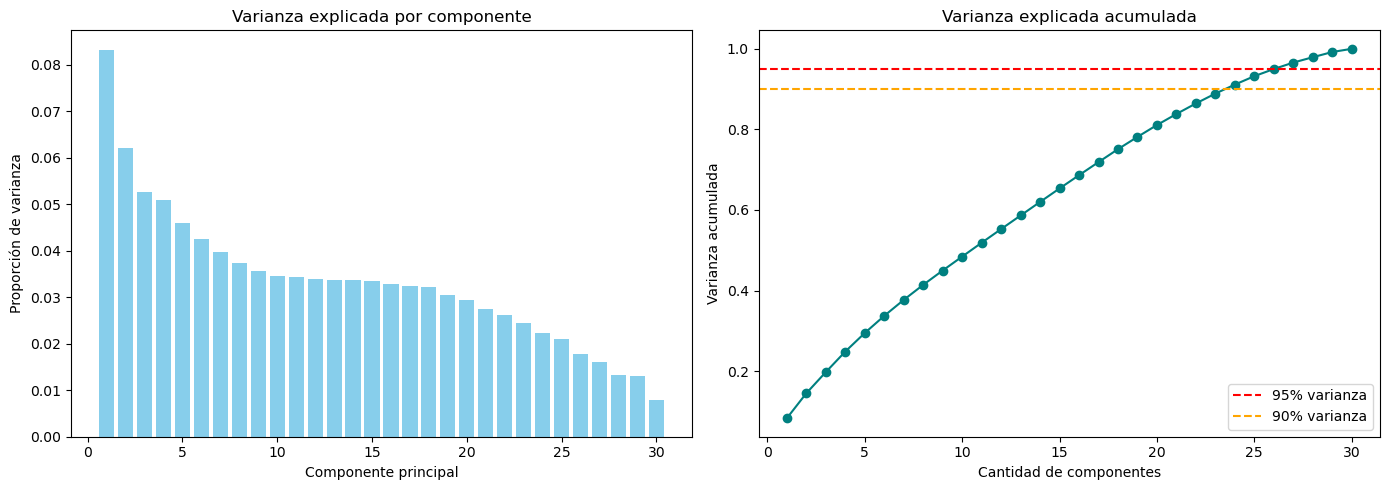

Componentes para 90% varianza: 24
Componentes para 95% varianza: 27


In [224]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Aplicar PCA sobre los datos escalados
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)

# Varianza explicada por cada componente
varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

# Graficar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(varianza_explicada)+1), varianza_explicada, color='skyblue')
axes[0].set_title('Varianza explicada por componente')
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Proporción de varianza')

axes[1].plot(range(1, len(varianza_acumulada)+1), varianza_acumulada, marker='o', color='teal')
axes[1].axhline(y=0.95, color='red', linestyle='--', label='95% varianza')
axes[1].axhline(y=0.90, color='orange', linestyle='--', label='90% varianza')
axes[1].set_title('Varianza explicada acumulada')
axes[1].set_xlabel('Cantidad de componentes')
axes[1].set_ylabel('Varianza acumulada')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Componentes para 90% varianza: {np.argmax(varianza_acumulada >= 0.90) + 1}")
print(f"Componentes para 95% varianza: {np.argmax(varianza_acumulada >= 0.95) + 1}")

El análisis de PCA muestra que la varianza está distribuida de forma relativamente uniforme entre las componentes principales, requiriendo 
27-28 de las 30 componentes originales para retener el 95% de la varianza. Esto indica baja redundancia entre las variables tras la selección de features 
previamente realizada, por lo que PCA no resulta una técnica efectiva para reducir significativamente la dimensionalidad en este caso sin una pérdida 
considerable de información.

#### Ahora vamos a realizar la transfomaciones del X_test

Primero vamos a eliminar la variable 'has_availability'

In [226]:
X_test = X_test.drop(columns=['has_availability']).copy()

La siguiente variable host_identity_verified que vamos a codificar con 0 y 1 es

In [228]:
X_test['host_identity_verified'] = X_test['host_identity_verified'].map({'t': 1, 'f': 0})

Vamos a hacer el merge entre X_test y el csv de comunas

In [229]:
X_test = X_test.merge(comunas, left_on='neighbourhood_cleansed', right_on='barrio', how='left')
X_test = X_test.drop(columns=['neighbourhood_cleansed', 'barrio']).copy()

Ahora vamos a realizar el OHE de las variables comuna y room_type

In [230]:
ohe_test = ohe.transform(X_test[['comuna', 'room_type']])
ohe_cols = ohe.get_feature_names_out(['comuna', 'room_type'])
ohe_test_df = pd.DataFrame(ohe_test, columns=ohe_cols, index=X_test.index)

X_test = X_test.drop(columns=['comuna', 'room_type'])
X_test = pd.concat([X_test, ohe_test_df], axis=1)

Ahora vamos a imputar los nulos con el simple imputer ya fiteado

In [231]:
columnas_imputar = ['review_scores_rating', 'review_scores_location', 
                     'minimum_nights', 'maximum_nights', 'bedrooms']
X_test[columnas_imputar] = imputer.transform(X_test[columnas_imputar])

Aplicamos el mismo filtro de P value que utilizamos en el X_train

In [232]:
X_test = X_test[seleccionadas].copy()

Y por ultimo hacemos el escalamiento

In [234]:
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [235]:
X_test_scaled.shape

(7952, 30)

In [236]:
X_test_scaled.head()

,number_of_reviews_ltm,coffee,review_scores_rating,parking,maximum_nights,review_scores_location,availability_60,gym,room_type_Private room,hosts_time_as_user_months,air_conditioning,host_listings_count,comuna_14,pool,minimum_nights,accommodates,hosts_time_as_host_months,wifi,comuna_3,room_type_Shared room,latitude,comuna_10,comuna_2,comuna_6,comuna_9,comuna_12,comuna_11,room_type_Hotel room,comuna_7,comuna_4
0,-0.706522,-1.365989,0.633628,-1.155300,1.230843,0.536822,-1.618340,-0.381286,3.287904,0.527090,0.685036,-0.468615,-0.700799,-0.604042,-0.104913,-1.255030,0.860116,0.09028,-0.21681,-0.069817,-0.386647,-0.062849,-0.403242,-0.126229,-0.047632,-0.154031,-0.09028,-0.029378,-0.084971,-0.120142
1,2.584799,-1.365989,0.450253,0.865576,-0.939057,0.221239,-1.044013,-0.381286,-0.304145,-1.281945,0.685036,-0.439395,-0.700799,1.655514,-0.163997,-0.616169,-0.739743,0.09028,-0.21681,-0.069817,-1.084852,-0.062849,-0.403242,-0.126229,-0.047632,-0.154031,-0.09028,-0.029378,-0.084971,-0.120142
2,-0.706522,0.732070,-0.894503,0.865576,-1.283486,0.536822,0.918271,-0.381286,-0.304145,-0.840204,-1.459777,-0.439395,-0.700799,-0.604042,-0.104913,1.300412,-0.445032,0.09028,-0.21681,-0.069817,-0.443813,-0.062849,-0.403242,-0.126229,-0.047632,-0.154031,-0.09028,-0.029378,-0.084971,-0.120142
3,-0.533295,-1.365989,0.633628,0.865576,-0.514262,0.536822,0.583247,-0.381286,-0.304145,0.569160,0.685036,4.849447,-0.700799,-0.604042,-0.104913,0.661551,1.112726,0.09028,-0.21681,-0.069817,-0.239654,-0.062849,-0.403242,-0.126229,-0.047632,-0.154031,-0.09028,-0.029378,-0.084971,-0.120142
4,0.332842,0.732070,-0.711127,0.865576,-0.514262,0.536822,0.343944,-0.381286,-0.304145,1.452642,0.685036,2.248856,-0.700799,-0.604042,-0.104913,0.661551,1.996859,0.09028,-0.21681,-0.069817,0.080512,-0.062849,2.479900,-0.126229,-0.047632,-0.154031,-0.09028,-0.029378,-0.084971,-0.120142


Dado que el análisis de PCA sobre `X_train` mostró que la varianza está distribuida de forma relativamente uniforme entre las componentes (requiriendo 
~27-28 de 30 componentes para retener el 95% de la varianza), se decidió **no aplicar PCA** como técnica de reducción de dimensionalidad. Esta decisión 
se mantiene de forma consistente para `X_test`, que conserva las mismas features seleccionadas que `X_train`.